# Capítulo 4: 4 PerformanceMetrics

Este cuaderno unificado contiene todos los ejemplos y ejercicios del capítulo.
Puede ejecutarse de forma independiente en Google Colab.

**Nota:** Este cuaderno incluye automáticamente todas las funciones compartidas necesarias.

# Funciones Compartidas

Este cuaderno incluye todas las funciones compartidas necesarias para ejecutar los ejemplos.
Estas funciones se cargan automáticamente al inicio del cuaderno.

(shared_functions)=
# Funciones compartidas

Este cuaderno contiene funciones que se reutilizan comúnmente en el libro, para cargar y guardar datos, ajustar y evaluar modelos de predicción, o graficar resultados. 

El cuaderno se puede descargar desde GitHub con

```
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.ipynb

```

El cuaderno se puede incluir en otros cuadernos usando

```
%run shared_functions
```



## Imports generales

In [1]:
# General
import os
import pandas as pd
import numpy as np
import math
import sys
import time
import pickle
import json
import datetime
import random

#import sklearn
import sklearn
from sklearn import *

%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid', {'axes.facecolor': '0.9'})

import graphviz
import xgboost

# Para aprendizaje con datos desbalanceados
import imblearn

import warnings
warnings.filterwarnings('ignore')



## Carga y guardado de datos

### read_from_files

Primer uso en [Capítulo 3, Transformación de Características Baseline](Baseline_Feature_Transformation).

In [2]:
# Cargar un conjunto de archivos pickle, juntarlos en un solo DataFrame, y ordenarlos por tiempo
# Toma como entrada la carpeta DIR_INPUT donde se almacenan los archivos, y BEGIN_DATE y END_DATE
def read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE):
    
    files = [os.path.join(DIR_INPUT, f) for f in os.listdir(DIR_INPUT) if f>=BEGIN_DATE+'.pkl' and f<=END_DATE+'.pkl']

    frames = []
    for f in files:
        df = pd.read_pickle(f)
        frames.append(df)
        del df
    df_final = pd.concat(frames)
    
    df_final=df_final.sort_values('TRANSACTION_ID')
    df_final.reset_index(drop=True,inplace=True)
    #  Note: -1 are missing values for real world data 
    df_final=df_final.replace([-1],0)
    
    return df_final


### save_object


In [3]:
# Guardar objeto como archivo pickle
def save_object(obj, filename):
    with open(filename, 'wb') as output:
        pickle.dump(obj, output, pickle.HIGHEST_PROTOCOL)


## Data preprocessing

### scaleData

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [4]:
def scaleData(train,test,features):
    scaler = sklearn.preprocessing.StandardScaler()
    scaler.fit(train[features])
    train[features]=scaler.transform(train[features])
    test[features]=scaler.transform(test[features])
    
    return (train,test)

## Train/Test splitting strategies

### get_train_test_set

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Ratio de muestreo agregado en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [5]:
def get_train_test_set(transactions_df,
                       start_date_training,
                       delta_train=7,delta_delay=7,delta_test=7,
                       sampling_ratio=1.0,
                       random_state=0):
    
    # Obtener los datos del conjunto de entrenamiento
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    # Obtener los datos del conjunto de prueba
    test_df = []
    
    # Nota: Las tarjetas conocidas como comprometidas después del período de retraso se eliminan del conjunto de prueba
    # Es decir, para cada día de prueba, todos los fraudes conocidos en (test_day-delay_period) se eliminan
    
    # Primero, obtener clientes conocidos como defraudados del conjunto de entrenamiento
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Obtener el día inicial relativo del conjunto de entrenamiento (más fácil que TX_DATETIME para recopilar datos de prueba)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Luego, para cada día del conjunto de prueba
    for day in range(delta_test):
    
        # Obtener datos de prueba para ese día
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Compromised cards from that test day, minus the delay period, are added to the pool of known defrauded customers
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # If subsample
    if sampling_ratio<1:
        
        train_df_frauds=train_df[train_df.TX_FRAUD==1].sample(frac=sampling_ratio, random_state=random_state)
        train_df_genuine=train_df[train_df.TX_FRAUD==0].sample(frac=sampling_ratio, random_state=random_state)
        train_df=pd.concat([train_df_frauds,train_df_genuine])
        
    # Sort data sets by ascending order of transaction ID
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, test_df)
                               


In [6]:
def get_train_delay_test_set(transactions_df,
                             start_date_training,
                             delta_train=7,delta_delay=7,delta_test=7,
                             sampling_ratio=1.0,
                             random_state=0):
    
    # Obtener los datos del conjunto de entrenamiento
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    # Obtener los datos del conjunto de retraso
    delay_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training+datetime.timedelta(days=delta_train)) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train)+
                                                                               +datetime.timedelta(days=delta_delay))]
    
    # Obtener los datos del conjunto de prueba
    test_df = []
    
    # Nota: Las tarjetas conocidas como comprometidas después del período de retraso se eliminan del conjunto de prueba
    # Es decir, para cada día de prueba, todos los fraudes conocidos en (test_day-delay_period) se eliminan
    
    # Primero, obtener clientes conocidos como defraudados del conjunto de entrenamiento
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Obtener el día inicial relativo del conjunto de entrenamiento (más fácil que TX_DATETIME para recopilar datos de prueba)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Luego, para cada día del conjunto de prueba
    for day in range(delta_test):
    
        # Obtener datos de prueba para ese día
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Compromised cards from that test day, minus the delay period, are added to the pool of known defrauded customers
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # If subsample
    if sampling_ratio<1:
        
        train_df_frauds=train_df[train_df.TX_FRAUD==1].sample(frac=sampling_ratio, random_state=random_state)
        train_df_genuine=train_df[train_df.TX_FRAUD==0].sample(frac=sampling_ratio, random_state=random_state)
        train_df=pd.concat([train_df_frauds,train_df_genuine])
        
    # Sort data sets by ascending order of transaction ID
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, delay_df, test_df)

### prequentialSplit

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [7]:
def prequentialSplit(transactions_df,
                     start_date_training, 
                     n_folds=4, 
                     delta_train=7,
                     delta_delay=7,
                     delta_assessment=7):
    
    prequential_split_indices=[]
        
    # For each fold
    for fold in range(n_folds):
        
        # Shift back start date for training by the fold index times the assessment period (delta_assessment)
        # (See Fig. 5)
        start_date_training_fold = start_date_training-datetime.timedelta(days=fold*delta_assessment)
        
        # Obtener los conjuntos de entrenamiento y prueba (evaluación)
        (train_df, test_df)=get_train_test_set(transactions_df,
                                               start_date_training=start_date_training_fold,
                                               delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_assessment)
    
        # Obtener los índices de los dos conjuntos, y agregarlos a la lista de divisiones prequenciales
        indices_train=list(train_df.index)
        indices_test=list(test_df.index)
        
        prequential_split_indices.append((indices_train,indices_test))
    
    return prequential_split_indices


## Predictions functions

### fit_model_and_get_predictions

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [8]:
def fit_model_and_get_predictions(classifier, train_df, test_df, 
                                  input_features, output_feature="TX_FRAUD",scale=True):

    # Por defecto, escala los datos de entrada
    if scale:
        (train_df, test_df)=scaleData(train_df,test_df,input_features)
    
    # Primero entrenamos el clasificador usando el método `fit`, y pasamos como argumentos las características de entrada y salida
    start_time=time.time()
    classifier.fit(train_df[input_features], train_df[output_feature])
    training_execution_time=time.time()-start_time

    # Luego obtenemos las predicciones en los datos de entrenamiento y prueba usando el método `predict_proba`
    # Las predicciones se devuelven como un array de numpy, que proporciona la probabilidad de fraude para cada transacción 
    start_time=time.time()
    predictions_test=classifier.predict_proba(test_df[input_features])[:,1]
    prediction_execution_time=time.time()-start_time
    
    predictions_train=classifier.predict_proba(train_df[input_features])[:,1]

    # El resultado se devuelve como un diccionario que contiene los modelos ajustados, 
    # y las predicciones en los conjuntos de entrenamiento y prueba
    model_and_predictions_dictionary = {'classifier': classifier,
                                        'predictions_test': predictions_test,
                                        'predictions_train': predictions_train,
                                        'training_execution_time': training_execution_time,
                                        'prediction_execution_time': prediction_execution_time
                                       }
    
    return model_and_predictions_dictionary

## Performance assessment

### card_precision_top_k_day

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Detallado en [Capítulo 4, Métricas de Precisión Top-K](Precision_Top_K_Metrics).

In [9]:
def card_precision_top_k_day(df_day,top_k):
    
    # Esto toma el máximo de las predicciones Y el máximo de la etiqueta TX_FRAUD para cada CUSTOMER_ID, 
    # y ordena por orden decreciente de predicción fraudulenta
    df_day = df_day.groupby('CUSTOMER_ID').max().sort_values(by="predictions", ascending=False).reset_index(drop=False)
            
    # Obtener las k tarjetas más sospechosas
    df_day_top_k=df_day.head(top_k)
    list_detected_compromised_cards=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].CUSTOMER_ID)
    
    # Compute precision top k
    card_precision_top_k = len(list_detected_compromised_cards) / top_k
    
    return list_detected_compromised_cards, card_precision_top_k



### card_precision_top_k

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).
Detallado en [Capítulo 4, Métricas de Precisión Top-K](Precision_Top_K_Metrics).

In [ ]:
def card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True):

    # Ordenar días por orden creciente
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()
    
    # Al principio, la lista de tarjetas comprometidas detectadas está vacía
    list_detected_compromised_cards = []
    
    card_precision_top_k_per_day_list = []
    nb_compromised_cards_per_day = []
    
    # For each day, compute precision top k
    for day in list_days:
        
        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]
        
        # Eliminemos las tarjetas comprometidas detectadas del conjunto de transacciones diarias
        df_day = df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)==False]
        
        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))
        
        detected_compromised_cards, card_precision_top_k = card_precision_top_k_day(df_day,top_k)
        
        card_precision_top_k_per_day_list.append(card_precision_top_k)
        
        # Actualicemos la lista de tarjetas comprometidas detectadas
        if remove_detected_compromised_cards:
            list_detected_compromised_cards.extend(detected_compromised_cards)
        
    # Compute the mean
    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()
    
    # Returns precision top k per day as a list, and resulting mean
    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k



### card_precision_top_k_custom

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
def card_precision_top_k_custom(y_true, y_pred, top_k, transactions_df):
    
    # Creemos un DataFrame predictions_df, que contiene todas las transacciones que coinciden con los índices del fold actual
    # (índices del vector y_true)
    predictions_df=transactions_df.iloc[y_true.index.values].copy()
    predictions_df['predictions']=y_pred
    
    # Compute the CP@k using the function implemented in Chapter 4, Section 4.2
    nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k=\
        card_precision_top_k(predictions_df, top_k)
    
    # Return the mean_card_precision_top_k
    return mean_card_precision_top_k


### performance_assessment

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [12]:
def performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                           prediction_feature='predictions', top_k_list=[100],
                           rounded=True):
    
    AUC_ROC = metrics.roc_auc_score(predictions_df[output_feature], predictions_df[prediction_feature])
    AP = metrics.average_precision_score(predictions_df[output_feature], predictions_df[prediction_feature])
    
    performances = pd.DataFrame([[AUC_ROC, AP]], 
                           columns=['AUC ROC','Average precision'])
    
    for top_k in top_k_list:
    
        _, _, mean_card_precision_top_k = card_precision_top_k(predictions_df, top_k)
        performances['Card Precision@'+str(top_k)]=mean_card_precision_top_k
        
    if rounded:
        performances = performances.round(3)
    
    return performances


### performance_assessment_model_collection

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [13]:
def performance_assessment_model_collection(fitted_models_and_predictions_dictionary, 
                                            transactions_df, 
                                            type_set='test',
                                            top_k_list=[100]):

    performances=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        predictions_df=transactions_df
            
        predictions_df['predictions']=model_and_predictions['predictions_'+type_set]
        
        performances_model=performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                                                   prediction_feature='predictions', top_k_list=top_k_list)
        performances_model.index=[classifier_name]
        
        performances=performances.append(performances_model)
        
    return performances

### execution_times_model_collection

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [14]:
def execution_times_model_collection(fitted_models_and_predictions_dictionary):

    execution_times=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        execution_times_model=pd.DataFrame() 
        execution_times_model['Training execution time']=[model_and_predictions['training_execution_time']]
        execution_times_model['Prediction execution time']=[model_and_predictions['prediction_execution_time']]
        execution_times_model.index=[classifier_name]
        
        execution_times=execution_times.append(execution_times_model)
        
    return execution_times

### get_class_from_fraud_probability

Primer uso en [Capítulo 4, Métricas Basadas en Umbral](Threshold_Based_Metrics).

In [15]:
# Getting classes from a vector of fraud probabilities and a threshold
def get_class_from_fraud_probability(fraud_probabilities, threshold=0.5):
    
    predicted_classes = [0 if fraud_probability<threshold else 1 
                         for fraud_probability in fraud_probabilities]

    return predicted_classes


### threshold_based_metrics

Primer uso en [Capítulo 4, Métricas Basadas en Umbral](Threshold_Based_Metrics).

In [16]:
def threshold_based_metrics(fraud_probabilities, true_label, thresholds_list):
    
    results = []
    
    for threshold in thresholds_list:
    
        predicted_classes = get_class_from_fraud_probability(fraud_probabilities, threshold=threshold)
    
        (TN, FP, FN, TP) = metrics.confusion_matrix(true_label, predicted_classes).ravel()
    
        MME = (FP+FN)/(TN+FP+FN+TP)
    
        TPR = TP/(TP+FN)
        TNR = TN/(TN+FP)
    
        FPR = FP/(TN+FP)
        FNR = FN/(TP+FN)
        
        BER = 1/2*(FPR+FNR)
        
        Gmean = np.sqrt(TPR*TNR)
    
        precision = 1 # 1 if TP+FP=0
        FDR = 1 # 1 if TP+FP=0
        
        if TP+FP>0:
            precision = TP/(TP+FP)
            FDR=FP/(TP+FP)
        
        NPV = 1 # 1 if TN+FN=0
        FOR = 1 # 1 if TN+FN=0
        
        if TN+FN>0:
            NPV = TN/(TN+FN)
            FOR = FN/(TN+FN)
            
        
        F1_score = 2*(precision*TPR)/(precision+TPR)
    
        results.append([threshold, MME, TPR, TNR, FPR, FNR, BER, Gmean, precision, NPV, FDR, FOR, F1_score])
        
    results_df = pd.DataFrame(results,columns=['Threshold' ,'MME', 'TPR', 'TNR', 'FPR', 'FNR', 'BER', 'G-mean', 'Precision', 'NPV', 'FDR', 'FOR', 'F1 Score'])
    
    return results_df

### get_summary_performances

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [17]:
def get_summary_performances(performances_df, parameter_column_name="Parameters summary"):

    metrics = ['AUC ROC','Average precision','Card Precision@100']
    performances_results=pd.DataFrame(columns=metrics)
    
    performances_df.reset_index(drop=True,inplace=True)

    best_estimated_parameters = []
    validation_performance = []
    test_performance = []
    
    for metric in metrics:
    
        index_best_validation_performance = performances_df.index[np.argmax(performances_df[metric+' Validation'].values)]
    
        best_estimated_parameters.append(performances_df[parameter_column_name].iloc[index_best_validation_performance])
        
        validation_performance.append(
                str(round(performances_df[metric+' Validation'].iloc[index_best_validation_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Validation'+' Std'].iloc[index_best_validation_performance],2))
        )
        
        test_performance.append(
                str(round(performances_df[metric+' Test'].iloc[index_best_validation_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Test'+' Std'].iloc[index_best_validation_performance],2))
        )
    
    performances_results.loc["Best estimated parameters"]=best_estimated_parameters
    performances_results.loc["Validation performance"]=validation_performance
    performances_results.loc["Test performance"]=test_performance

    optimal_test_performance = []
    optimal_parameters = []

    for metric in ['AUC ROC Test','Average precision Test','Card Precision@100 Test']:
    
        index_optimal_test_performance = performances_df.index[np.argmax(performances_df[metric].values)]
    
        optimal_parameters.append(performances_df[parameter_column_name].iloc[index_optimal_test_performance])
    
        optimal_test_performance.append(
                str(round(performances_df[metric].iloc[index_optimal_test_performance],3))+
                '+/-'+
                str(round(performances_df[metric+' Std'].iloc[index_optimal_test_performance],2))
        )

    performances_results.loc["Optimal parameter(s)"]=optimal_parameters
    performances_results.loc["Optimal test performance"]=optimal_test_performance
    
    return performances_results

### model_selection_performances

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [18]:
def model_selection_performances(performances_df_dictionary,
                                 performance_metric='AUC ROC'):
    
    # Nota: max_depth de 50 es similar a None
    default_parameters_dictionary={
        "Decision Tree": 50,
        "Logstic Regression": 1,
        "Random Forest": "100/50",
        "XGBoost": "100/0.1/2"
    }
    
    mean_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    std_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    # Para cada clase de modelo
    for model_class, performances_df in performances_df_dictionary.items():
        
        # Obtener los rendimientos para los parámetros por defecto
        default_performances=performances_df[performances_df['Parameters summary']==default_parameters_dictionary[model_class]]
        default_performances=default_performances.round(decimals=3)
        
        mean_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test"].values[0])
        std_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test Std"].values[0])
        
        # Obtener los rendimientos para los mejores parámetros estimados
        performances_summary=get_summary_performances(performances_df, parameter_column_name="Parameters summary")
        mean_std_performances=performances_summary.loc[["Test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[1]))
        
        # Obtener los rendimientos para los parámetros óptimos
        mean_std_performances=performances_summary.loc[["Optimal test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[1]))
        
    # Return the mean performances and their standard deviations    
    return (mean_performances_dictionary,std_performances_dictionary)

In [19]:
def model_selection_performances(performances_df_dictionary,
                                 performance_metric='AUC ROC',
                                 model_classes=['Decision Tree', 
                                                'Logistic Regression', 
                                                'Random Forest', 
                                                'XGBoost'],
                                 default_parameters_dictionary={
                                                "Decision Tree": 50,
                                                "Logistic Regression": 1,
                                                "Random Forest": "100/50",
                                                "XGBoost": "100/0.1/3"
                                            }):
    
    mean_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    std_performances_dictionary={
        "Default parameters": [],
        "Best validation parameters": [],
        "Optimal parameters": []
    }
    
    # Para cada clase de modelo
    for model_class in model_classes:
        
        performances_df=performances_df_dictionary[model_class]
        
        # Get the performances for the default paramaters
        default_performances=performances_df[performances_df['Parameters summary']==default_parameters_dictionary[model_class]]
        default_performances=default_performances.round(decimals=3)
        
        mean_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test"].values[0])
        std_performances_dictionary["Default parameters"].append(default_performances[performance_metric+" Test Std"].values[0])
        
        # Get the performances for the best estimated parameters
        performances_summary=get_summary_performances(performances_df, parameter_column_name="Parameters summary")
        mean_std_performances=performances_summary.loc[["Test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Best validation parameters"].append(float(mean_std_performances[1]))
        
        # Get the performances for the boptimal parameters
        mean_std_performances=performances_summary.loc[["Optimal test performance"]][performance_metric].values[0]
        mean_std_performances=mean_std_performances.split("+/-")
        mean_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[0]))
        std_performances_dictionary["Optimal parameters"].append(float(mean_std_performances[1]))
        
    # Return the mean performances and their standard deviations    
    return (mean_performances_dictionary,std_performances_dictionary)

## Model selection

### prequential_grid_search

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [20]:
def prequential_grid_search(transactions_df, 
                            classifier, 
                            input_features, output_feature, 
                            parameters, scoring, 
                            start_date_training, 
                            n_folds=4,
                            expe_type='Test',
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            n_jobs=-1):
    
    estimators = [('scaler', sklearn.preprocessing.StandardScaler()), ('clf', classifier)]
    pipe = sklearn.pipeline.Pipeline(estimators)
    
    prequential_split_indices=prequentialSplit(transactions_df,
                                               start_date_training=start_date_training, 
                                               n_folds=n_folds, 
                                               delta_train=delta_train, 
                                               delta_delay=delta_delay, 
                                               delta_assessment=delta_assessment)
    
    grid_search = sklearn.model_selection.GridSearchCV(pipe, parameters, scoring=scoring, cv=prequential_split_indices, refit=False, n_jobs=n_jobs)
    
    X=transactions_df[input_features]
    y=transactions_df[output_feature]

    grid_search.fit(X, y)
    
    performances_df=pd.DataFrame()
    
    for i in range(len(performance_metrics_list_grid)):
        performances_df[performance_metrics_list[i]+' '+expe_type]=grid_search.cv_results_['mean_test_'+performance_metrics_list_grid[i]]
        performances_df[performance_metrics_list[i]+' '+expe_type+' Std']=grid_search.cv_results_['std_test_'+performance_metrics_list_grid[i]]

    performances_df['Parameters']=grid_search.cv_results_['params']
    performances_df['Execution time']=grid_search.cv_results_['mean_fit_time']
    
    return performances_df



### model_selection_wrapper

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [21]:
def model_selection_wrapper(transactions_df, 
                            classifier, 
                            input_features, output_feature,
                            parameters, 
                            scoring, 
                            start_date_training_for_valid,
                            start_date_training_for_test,
                            n_folds=4,
                            delta_train=7, 
                            delta_delay=7, 
                            delta_assessment=7,
                            performance_metrics_list_grid=['roc_auc'],
                            performance_metrics_list=['AUC ROC'],
                            n_jobs=-1):

    # Get performances on the validation set using prequential validation
    performances_df_validation=prequential_grid_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_valid,
                            n_folds=n_folds,
                            expe_type='Validation',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Get performances on the test set using prequential validation
    performances_df_test=prequential_grid_search(transactions_df, classifier, 
                            input_features, output_feature,
                            parameters, scoring, 
                            start_date_training=start_date_training_for_test,
                            n_folds=n_folds,
                            expe_type='Test',
                            delta_train=delta_train, 
                            delta_delay=delta_delay, 
                            delta_assessment=delta_assessment,
                            performance_metrics_list_grid=performance_metrics_list_grid,
                            performance_metrics_list=performance_metrics_list,
                            n_jobs=n_jobs)
    
    # Bind the two resulting DataFrames
    performances_df_validation.drop(columns=['Parameters','Execution time'], inplace=True)
    performances_df=pd.concat([performances_df_test,performances_df_validation],axis=1)

    # And return as a single DataFrame
    return performances_df


### kfold_cv_with_classifier

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [22]:
def kfold_cv_with_classifier(classifier,
                             X,
                             y,
                             n_splits=5,
                             strategy_name="Basline classifier"):
    
    cv = sklearn.model_selection.StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    cv_results_=sklearn.model_selection.cross_validate(classifier,X,y,cv=cv,
                                                       scoring=['roc_auc',
                                                                'average_precision',
                                                                'balanced_accuracy'],
                                                       return_estimator=True)
    
    results=round(pd.DataFrame(cv_results_),3)
    results_mean=list(results.mean().values)
    results_std=list(results.std().values)
    results_df=pd.DataFrame([[str(round(results_mean[i],3))+'+/-'+
                              str(round(results_std[i],3)) for i in range(len(results))]],
                            columns=['Fit time (s)','Score time (s)',
                                     'AUC ROC','Average Precision','Balanced accuracy'])
    results_df.rename(index={0:strategy_name}, inplace=True)
    
    classifier_0=cv_results_['estimator'][0]
    
    (train_index, test_index) = next(cv.split(X, y))
    train_df=pd.DataFrame({'X1':X[train_index,0],'X2':X[train_index,1], 'Y':y[train_index]})
    test_df=pd.DataFrame({'X1':X[test_index,0],'X2':X[test_index,1], 'Y':y[test_index]})
    
    return (results_df, classifier_0, train_df, test_df)

## Plotting

### get_tx_stats

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [23]:
# Compute the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_tx_stats(transactions_df, start_date_df="2018-04-01"):
    
    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraudulent_transactions_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of fraudulent cards per day
    nb_compromised_card_per_day=transactions_df[transactions_df['TX_FRAUD']==1].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()
    
    tx_stats=pd.DataFrame({"nb_tx_per_day":nb_tx_per_day,
                           "nb_fraudulent_transactions_per_day":nb_fraudulent_transactions_per_day,
                           "nb_compromised_cards_per_day":nb_compromised_card_per_day})

    tx_stats=tx_stats.reset_index()
    
    start_date = datetime.datetime.strptime(start_date_df, "%Y-%m-%d")
    tx_date=start_date+tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)
    
    tx_stats['tx_date']=tx_date
    
    return tx_stats



### get_template_tx_stats

Primer uso en [Capítulo 3, Sistema de Detección de Fraude Baseline](Baseline_FDS).

In [24]:
# Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_template_tx_stats(ax ,fs,
                          start_date_training,
                          title='',
                          delta_train=7,
                          delta_delay=7,
                          delta_test=7,
                          ylim=300):
    
    ax.set_title(title, fontsize=fs*1.5)
    ax.set_ylim([0, ylim])
    
    ax.set_xlabel('Date', fontsize=fs)
    ax.set_ylabel('Number', fontsize=fs)
    
    plt.yticks(fontsize=fs*0.7) 
    plt.xticks(fontsize=fs*0.7)    

    ax.axvline(start_date_training+datetime.timedelta(days=delta_train), 0,ylim, color="black")
    ax.axvline(start_date_training+datetime.timedelta(days=delta_train+delta_delay), 0, ylim, color="black")
    
    ax.text(start_date_training+datetime.timedelta(days=2), ylim-20,'Training period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+2), ylim-20,'Delay period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+delta_delay+2), ylim-20,'Test period', fontsize=fs)


### get_template_roc_curve

Primer uso en [Capítulo 4, Métricas Libres de Umbral](Threshold_Free_Metrics).

In [25]:
def get_template_roc_curve(ax, title,fs,random=True):
    
    ax.set_title(title, fontsize=fs)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    
    ax.set_xlabel('False Positive Rate', fontsize=fs)
    ax.set_ylabel('True Positive Rate', fontsize=fs)
    
    if random:
        ax.plot([0, 1], [0, 1],'r--',label="AUC ROC Random = 0.5")



### get_template_pr_curve

Primer uso en [Capítulo 4, Métricas Libres de Umbral](Threshold_Free_Metrics).

In [26]:
def get_template_pr_curve(ax, title,fs, baseline=0.5):
    ax.set_title(title, fontsize=fs)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    
    ax.set_xlabel('Recall (True Positive Rate)', fontsize=fs)
    ax.set_ylabel('Precision', fontsize=fs)
    
    ax.plot([0, 1], [baseline, baseline],'r--',label='AP Random = {0:0.3f}'.format(baseline))


### get_performance_plot

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [ ]:
# Obtener el gráfico de rendimiento para una única métrica de rendimiento
def get_performance_plot(performances_df, 
                         ax, 
                         performance_metric, 
                         expe_type_list=['Test','Train'], 
                         expe_type_color_list=['#008000','#2F4D7E'],
                         parameter_name="Tree maximum depth",
                         summary_performances=None):
    
    # expe_type_list is the list of type of experiments, typically containing 'Test', 'Train', or 'Valid'
    # Para todos los tipos de experimentos
    for i in range(len(expe_type_list)):
    
        # Columna en performances_df para la cual recuperar los datos 
        performance_metric_expe_type=performance_metric+' '+expe_type_list[i]
    
        # Plot data on graph
        ax.plot(performances_df['Parameters summary'], performances_df[performance_metric_expe_type], 
                color=expe_type_color_list[i], label = expe_type_list[i])
        
        # If performances_df contains confidence intervals, add them to the graph
        if performance_metric_expe_type+' Std' in performances_df.columns:
        
            conf_min = performances_df[performance_metric_expe_type]\
                        -2*performances_df[performance_metric_expe_type+' Std']
            conf_max = performances_df[performance_metric_expe_type]\
                        +2*performances_df[performance_metric_expe_type+' Std']
    
            ax.fill_between(performances_df['Parameters summary'], conf_min, conf_max, color=expe_type_color_list[i], alpha=.1)

    # If summary_performances table is present, adds vertical dashed bar for best estimated parameter 
    if summary_performances is not None:
        best_estimated_parameter=summary_performances[performance_metric][['Best estimated parameters']].values[0]
        best_estimated_performance=float(summary_performances[performance_metric][['Validation performance']].values[0].split("+/-")[0])
        ymin, ymax = ax.get_ylim()
        ax.vlines(best_estimated_parameter, ymin, best_estimated_performance,
                  linestyles="dashed")
    
    # Set title, and x and y axes labels
    ax.set_title(performance_metric+'\n', fontsize=14)
    ax.set(xlabel = parameter_name, ylabel=performance_metric)
    

### get_performances_plots

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [28]:
# Get the performance plots for a set of performance metric
def get_performances_plots(performances_df, 
                           performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'], 
                           expe_type_list=['Test','Train'], expe_type_color_list=['#008000','#2F4D7E'],
                           parameter_name="Tree maximum depth",
                           summary_performances=None):
    
    # Create as many graphs as there are performance metrics to display
    n_performance_metrics = len(performance_metrics_list)
    fig, ax = plt.subplots(1, n_performance_metrics, figsize=(5*n_performance_metrics,4))
    
    # Plot performance metric for each metric in performance_metrics_list
    for i in range(n_performance_metrics):
    
        get_performance_plot(performances_df, ax[i], performance_metric=performance_metrics_list[i], 
                             expe_type_list=expe_type_list, 
                             expe_type_color_list=expe_type_color_list,
                             parameter_name=parameter_name,
                             summary_performances=summary_performances)
    
    ax[n_performance_metrics-1].legend(loc='upper left', 
                                       labels=expe_type_list, 
                                       bbox_to_anchor=(1.05, 1),
                                       title="Type set")

    plt.subplots_adjust(wspace=0.5, 
                        hspace=0.8)

### get_execution_times_plot

Primer uso en [Capítulo 5, Estrategias de Validación](Validation_Strategies).

In [29]:
# Get the performance plot for a single performance metric
def get_execution_times_plot(performances_df,
                             title="",
                             parameter_name="Tree maximum depth"):
    
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    
    # Plot data on graph
    ax.plot(performances_df['Parameters summary'], performances_df["Execution time"], 
            color="black")
        
    # Set title, and x and y axes labels
    ax.set_title(title, fontsize=14)
    ax.set(xlabel = parameter_name, ylabel="Execution time (seconds)")

### get_model_selection_performances_plots

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [ ]:
# Obtener el gráfico de rendimiento para una única métrica de rendimiento
def get_model_selection_performance_plot(performances_df_dictionary, 
                                         ax, 
                                         performance_metric,
                                         ylim=[0,1],
                                         model_classes=['Decision Tree', 
                                                        'Logistic Regression', 
                                                        'Random Forest', 
                                                        'XGBoost']):
    
    
    (mean_performances_dictionary,std_performances_dictionary) = \
        model_selection_performances(performances_df_dictionary=performances_df_dictionary,
                                     performance_metric=performance_metric)
    
    
    # ancho de las barras
    barWidth = 0.3
    # La posición x de las barras
    r1 = np.arange(len(model_classes))
    r2 = r1+barWidth
    r3 = r1+2*barWidth
    
    # Crear barras de parámetros por defecto (Naranja)
    ax.bar(r1, mean_performances_dictionary['Default parameters'], 
           width = barWidth, color = '#CA8035', edgecolor = 'black', 
           yerr=std_performances_dictionary['Default parameters'], capsize=7, label='Default parameters')
 
    # Create Best validation parameters bars (Red)
    ax.bar(r2, mean_performances_dictionary['Best validation parameters'], 
           width = barWidth, color = '#008000', edgecolor = 'black', 
           yerr=std_performances_dictionary['Best validation parameters'], capsize=7, label='Best validation parameters')

    # Create Optimal parameters bars (Green)
    ax.bar(r3, mean_performances_dictionary['Optimal parameters'], 
           width = barWidth, color = '#2F4D7E', edgecolor = 'black', 
           yerr=std_performances_dictionary['Optimal parameters'], capsize=7, label='Optimal parameters')
 

    # Set title, and x and y axes labels
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xticks(r2+barWidth/2)
    ax.set_xticklabels(model_classes, rotation = 45, ha="right", fontsize=12)
    ax.set_title(performance_metric+'\n', fontsize=18)
    ax.set_xlabel("Model class", fontsize=16)
    ax.set_ylabel(performance_metric, fontsize=15)

### get_model_selection_performances_plots

Primer uso en [Capítulo 5, Selección de Modelos](Model_Selection).

In [31]:
def get_model_selection_performances_plots(performances_df_dictionary, 
                                           performance_metrics_list=['AUC ROC', 'Average precision', 'Card Precision@100'],
                                           ylim_list=[[0.6,0.9],[0.2,0.8],[0.2,0.35]],
                                           model_classes=['Decision Tree', 
                                                          'Logistic Regression', 
                                                          'Random Forest', 
                                                          'XGBoost']):
    
    # Create as many graphs as there are performance metrics to display
    n_performance_metrics = len(performance_metrics_list)
    fig, ax = plt.subplots(1, n_performance_metrics, figsize=(5*n_performance_metrics,4))
    
    parameter_types=['Default parameters','Best validation parameters','Optimal parameters']
    
    # Plot performance metric for each metric in performance_metrics_list
    for i in range(n_performance_metrics):
    
        get_model_selection_performance_plot(performances_df_dictionary, 
                                             ax[i], 
                                             performance_metrics_list[i],
                                             ylim=ylim_list[i],
                                             model_classes=model_classes
                                            )
    
    ax[n_performance_metrics-1].legend(loc='upper left', 
                                       labels=parameter_types, 
                                       bbox_to_anchor=(1.05, 1),
                                       title="Parameter type",
                                       prop={'size': 12},
                                       title_fontsize=12)

    plt.subplots_adjust(wspace=0.5, 
                        hspace=0.8)

### plot_decision_boundary_classifier

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [32]:
def plot_decision_boundary_classifier(ax, 
                                      classifier,
                                      train_df,
                                      input_features=['X1','X2'],
                                      output_feature='Y',
                                      title="",
                                      fs=14,
                                      plot_training_data=True):

    plot_colors = ["tab:blue","tab:orange"]

    x1_min, x1_max = train_df[input_features[0]].min() - 1, train_df[input_features[0]].max() + 1
    x2_min, x2_max = train_df[input_features[1]].min() - 1, train_df[input_features[1]].max() + 1
    
    plot_step=0.1
    xx, yy = np.meshgrid(np.arange(x1_min, x1_max, plot_step),
                         np.arange(x2_min, x2_max, plot_step))

    Z = classifier.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu_r,alpha=0.3)

    if plot_training_data:
        # Plot the training points
        groups = train_df.groupby(output_feature)
        for name, group in groups:
            ax.scatter(group[input_features[0]], group[input_features[1]], edgecolors='black', label=name)
        
    ax.set_title(title, fontsize=fs)
    ax.set_xlabel(input_features[0], fontsize=fs)
    ax.set_ylabel(input_features[1], fontsize=fs)

### plot_decision_boundary

Primer uso en [Capítulo 6, Aprendizaje sensible al costo](Cost_Sensitive_Learning).

In [33]:
def plot_decision_boundary(classifier_0,
                           train_df, 
                           test_df):
    
    fig_decision_boundary, ax = plt.subplots(1, 3, figsize=(5*3,5))

    plot_decision_boundary_classifier(ax[0], classifier_0,
                                  train_df,
                                  title="Decision surface of the decision tree\n With training data",
                                  plot_training_data=True)

    plot_decision_boundary_classifier(ax[1], classifier_0,
                                  train_df,
                                  title="Decision surface of the decision tree\n",
                                  plot_training_data=False)


    plot_decision_boundary_classifier(ax[2], classifier_0,
                                  test_df,
                                  title="Decision surface of the decision tree\n With test data",
                                  plot_training_data=True)

    ax[-1].legend(loc='upper left', 
              #labels=[0,1], 
              bbox_to_anchor=(1.05, 1),
              title="Class")

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu_r, norm=plt.Normalize(vmin=0, vmax=1))
    cax = fig_decision_boundary.add_axes([0.93, 0.15, 0.02, 0.5])
    fig_decision_boundary.colorbar(sm, cax=cax, alpha=0.3, boundaries=np.linspace(0, 1, 11))
    
    return fig_decision_boundary

## Deep Learning functions



In [34]:
import torch
import torch.nn.functional as F

### seed_everything

Primer uso en [Capítulo 7, Red neuronal de propagación hacia adelante](FeedForwardNeuralNetworks).

In [35]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

### Utilidades para gestión de datos, entrenamiento y evaluación

Primer uso en [Capítulo 7, Red neuronal de propagación hacia adelante](FeedForwardNeuralNetworks).

In [36]:
class FraudDataset(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        'Initialization'
        self.x = x
        self.y = y

    def __len__(self):
        'Denotes the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample index
        if self.y is not None:
            return self.x[index], self.y[index]
        else:
            return self.x[index]

def prepare_generators(training_set,valid_set,batch_size=64):
    
    train_loader_params = {'batch_size': batch_size,
              'shuffle': True,
              'num_workers': 0}
    valid_loader_params = {'batch_size': batch_size,
              'num_workers': 0}
    
    training_generator = torch.utils.data.DataLoader(training_set, **train_loader_params)
    valid_generator = torch.utils.data.DataLoader(valid_set, **valid_loader_params)
    
    return training_generator,valid_generator

def evaluate_model(model,generator,criterion):
    model.eval()
    batch_losses = []
    for x_batch, y_batch in generator:
        # Forward pass
        y_pred = model(x_batch)
        # Compute Loss
        loss = criterion(y_pred.squeeze(), y_batch)
        batch_losses.append(loss.item())
    mean_loss = np.mean(batch_losses)    
    return mean_loss

class EarlyStopping:
    
    def __init__(self, patience=2, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = np.Inf
    
    def continue_training(self,current_score):
        if self.best_score > current_score:
            self.best_score = current_score
            self.counter = 0
            if self.verbose:
                print("New best score:", current_score)
        else:
            self.counter+=1
            if self.verbose:
                print(self.counter, " iterations since best score.")
                
        return self.counter <= self.patience  
    
def training_loop(model,training_generator,valid_generator,optimizer,criterion,max_epochs=100,apply_early_stopping=True,patience=2,verbose=False):
    #Setting the model in training mode
    model.train()

    if apply_early_stopping:
        early_stopping = EarlyStopping(verbose=verbose,patience=patience)
    
    all_train_losses = []
    all_valid_losses = []
    
    #Training loop
    start_time=time.time()
    for epoch in range(max_epochs):
        model.train()
        train_loss=[]
        for x_batch, y_batch in training_generator:
            optimizer.zero_grad()
            # Forward pass
            y_pred = model(x_batch)
            # Compute Loss
            loss = criterion(y_pred.squeeze(), y_batch)
            # Backward pass
            loss.backward()
            optimizer.step()   
            train_loss.append(loss.item())
        
        #showing last training loss after each epoch
        all_train_losses.append(np.mean(train_loss))
        if verbose:
            print('')
            print('Epoch {}: train loss: {}'.format(epoch, np.mean(train_loss)))
        #evaluating the model on the test set after each epoch    
        valid_loss = evaluate_model(model,valid_generator,criterion)
        all_valid_losses.append(valid_loss)
        if verbose:
            print('valid loss: {}'.format(valid_loss))
        if apply_early_stopping:
            if not early_stopping.continue_training(valid_loss):
                if verbose:
                    print("Early stopping")
                break
        
    training_execution_time=time.time()-start_time
    return model,training_execution_time,all_train_losses,all_valid_losses

def per_sample_mse(model,generator):
    model.eval()
    criterion = torch.nn.MSELoss(reduction="none")
    batch_losses = []
    for x_batch, y_batch in generator:
        # Forward pass
        y_pred = model(x_batch)
        # Compute Loss
        loss = criterion(y_pred.squeeze(), y_batch)
        loss_app = list(torch.mean(loss,axis=1).detach().numpy())
        batch_losses.extend(loss_app)
    return batch_losses

class FraudDatasetForPipe(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        'Initialization'
        self.x = torch.FloatTensor(x)
        self.y = None
        if y is not None:
            self.y = torch.LongTensor(y.values)
        

    def __len__(self):
        'Denotes the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample index
        if self.y is not None:
            return self.x[index], self.y[index]
        else:
            return self.x[index], -1  
        
def rolling_window(array, window):
    a = np.concatenate([np.ones((window-1,))*-1,array])
    shape = a.shape[:-1] + (a.shape[-1] - window + 1, window)
    strides = a.strides + (a.strides[-1],)
    return np.lib.stride_tricks.as_strided(a, shape=shape, strides=strides).astype(int)

### FraudDatasetUnsupervised

Primer uso en [Capítulo 7, Autoencodificadores y detección de anomalías](Autoencoders).

In [37]:
class FraudDatasetUnsupervised(torch.utils.data.Dataset):
    
    def __init__(self, x,output=True):
        'Initialization'
        self.x = x
        self.output = output

    def __len__(self):
        'Denotes the total number of samples'
        return len(self.x)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample index
        if self.output:
            return self.x[index], self.x[index]
        else:
            return self.x[index]

### Módulos SimpleFraudMLPWithDropout y FraudMLP

Primer uso en [Capítulo 7, Red neuronal de propagación hacia adelante](FeedForwardNeuralNetworks).

In [38]:
class SimpleFraudMLPWithDropout(torch.nn.Module):
    
        def __init__(self, input_size, hidden_size,p):
            super(SimpleFraudMLPWithDropout, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            self.p = p
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 1)
            self.sigmoid = torch.nn.Sigmoid()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.sigmoid(output)
            
            return output
        
class FraudMLP(torch.nn.Module):
    
        def __init__(self, input_size,hidden_size=100,num_layers=1,p=0):
            super(FraudMLP, self).__init__()
            # parameters
            self.input_size = input_size
            self.hidden_size  = hidden_size
            self.p = p
            
            #input to hidden
            self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
            self.relu = torch.nn.ReLU()
            
            self.fc_hidden=[]
            for i in range(num_layers-1):
                self.fc_hidden.append(torch.nn.Linear(self.hidden_size, self.hidden_size))
                self.fc_hidden.append(torch.nn.ReLU())
                
            #hidden to output
            self.fc2 = torch.nn.Linear(self.hidden_size, 2)
            self.softmax = torch.nn.Softmax()
            
            self.dropout = torch.nn.Dropout(self.p)
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)             
            hidden = self.dropout(hidden)
            
            for layer in self.fc_hidden:
                hidden=layer(hidden)
                hidden = self.dropout(hidden)
            
            output = self.fc2(hidden)
            output = self.softmax(output)
            
            return output

### Módulo SimpleAutoencoder

Primer uso en [Capítulo 7, Autoencodificadores y detección de anomalías](Autoencoders).

In [39]:
class SimpleAutoencoder(torch.nn.Module):
    
        def __init__(self, input_size, intermediate_size, code_size):
            super(SimpleAutoencoder, self).__init__()
            # parameters
            self.input_size = input_size
            self.intermediate_size = intermediate_size           
            self.code_size  = code_size
            
            self.relu = torch.nn.ReLU()   
            
            #encoder
            self.fc1 = torch.nn.Linear(self.input_size, self.intermediate_size)
            self.fc2 = torch.nn.Linear(self.intermediate_size, self.code_size)
            
            #decoder 
            self.fc3 = torch.nn.Linear(self.code_size, self.intermediate_size)            
            self.fc4 = torch.nn.Linear(self.intermediate_size, self.input_size)
            
            
        def forward(self, x):
            
            hidden = self.fc1(x)
            hidden = self.relu(hidden)
            
            code = self.fc2(hidden)
            code = self.relu(code)
 
            hidden = self.fc3(code)
            hidden = self.relu(hidden)
            
            output = self.fc4(hidden)
            #linear activation in final layer)            
            
            return output

### Módulo de Atención

Primer uso en [Capítulo 7, Modelos secuenciales y aprendizaje de representación](SequentialModeling).

In [ ]:
# source : https://github.com/IBM/pytorch-seq2seq/blob/master/seq2seq/models/attention.py

class Attention(torch.nn.Module):
    r"""
    Aplica un mecanismo de atención sobre las características de salida del decodificador.
    .. math::
            \begin{array}{ll}
            x = context*output \\
            attn = exp(x_i) / sum_j exp(x_j) \\
            output = \tanh(w * (attn * context) + b * output)
            \end{array}
    Args:
        dim(int): El número de características esperadas en la salida
    Inputs: output, context
        - **output** (batch, output_len, dimensions): tensor que contiene las características de salida del decodificador.
        - **context** (batch, input_len, dimensions): tensor que contiene características de la secuencia de entrada codificada.
    Outputs: output, attn
        - **output** (batch, output_len, dimensions): tensor que contiene las características de salida atendidas del decodificador.
        - **attn** (batch, output_len, input_len): tensor que contiene los pesos de atención.
    Attributes:
        linear_out (torch.nn.Linear): applies a linear transformation to the incoming data: :math:`y = Ax + b`.
        mask (torch.Tensor, optional): applies a :math:`-inf` to the indices specified in the `Tensor`.
    Examples::
         >>> attention = seq2seq.models.Attention(256)
         >>> context = Variable(torch.randn(5, 3, 256))
         >>> output = Variable(torch.randn(5, 5, 256))
         >>> output, attn = attention(output, context)
    """
    def __init__(self, dim):
        super(Attention, self).__init__()
        self.linear_out = torch.nn.Linear(dim*2, dim)
        self.mask = None

    def set_mask(self, mask):
        """
        Sets indices to be masked
        Args:
            mask (torch.Tensor): tensor containing indices to be masked
        """
        self.mask = mask

    def forward(self, output, context):
        batch_size = output.size(0)
        hidden_size = output.size(2)
        input_size = context.size(1)
        # (batch, out_len, dim) * (batch, in_len, dim) -> (batch, out_len, in_len)
        attn = torch.bmm(output, context.transpose(1, 2))
        if self.mask is not None:
            attn.data.masked_fill_(self.mask, -float('inf'))
        attn = F.softmax(attn.view(-1, input_size), dim=1).view(batch_size, -1, input_size)

        # (batch, out_len, in_len) * (batch, in_len, dim) -> (batch, out_len, dim)
        mix = torch.bmm(attn, context)

        # concat -> (batch, out_len, 2*dim)
        combined = torch.cat((mix, output), dim=2)
        # output -> (batch, out_len, dim)
        output = F.tanh(self.linear_out(combined.view(-1, 2 * hidden_size))).view(batch_size, -1, hidden_size)

        return output, attn



---

## ThresholdBased


(Threshold_Based_Metrics)=
# Métricas basadas en umbral

La detección de fraude se aborda más comúnmente como un problema de clasificación binaria: Un sistema de detección de fraude recibe transacciones, y su objetivo es predecir si es probable que sean genuinas o fraudulentas. Dada una transacción $x$ (con características $x_1$, $x_2$, ...), un sistema de detección de fraude produce una puntuación de fraude y la clasifica como genuina o fraudulenta, como se ilustra en la Fig. 1. 

![](images/transaction_fraud_score_with_caption.png)

Las puntuaciones de fraude devueltas por un sistema de detección de fraude en un conjunto de transacciones solo necesitan estar *ordenadas*. Cuanto mayor sea su valor, mayor será la probabilidad de que la transacción sea un fraude. Por simplicidad, asumiremos en lo siguiente que la puntuación de fraude es la probabilidad $p(x)$ de que una transacción $x$ sea un fraude, es decir, un valor entre 0 y 1.

La decisión de clasificar una transacción como fraudulenta se puede tomar estableciendo un umbral $0 \le t \le 1$ en la probabilidad $p(x)$, de modo que si $p(x) > t$, la transacción se clasifica como fraudulenta, o como genuina si $p(x) \le t$.

In [41]:
# Inicialización: Cargar funciones compartidas

# Cargar funciones compartidas
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

# For plotting confusion matrices
from pretty_plot_confusion_matrix import plot_confusion_matrix_from_data


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 63257  100 63257    0     0   188k      0 --:--:-- --:--:-- --:--:--  190k


In [42]:
# Getting classes from a vector of fraud probabilities and a threshold
def get_class_from_fraud_probability(fraud_probabilities, threshold=0.5):
    
    predicted_classes = [0 if fraud_probability<threshold else 1 
                         for fraud_probability in fraud_probabilities]

    return predicted_classes

## Matriz de confusión 


Una vez que se establece un umbral $t$, el resultado de un problema de clasificación binaria generalmente se representa como una *matriz de confusión*. Denotando por $Y_1$ el conjunto de instancias positivas (fraudes), $Y_0$ el conjunto de instancias negativas (genuinas), $\hat{Y}_1$ el conjunto de instancias predichas como positivas y $\hat{Y}_0$ las predichas como negativas, la matriz de confusión se representa de la siguiente manera, ver Fig. 2 {cite}`tharwat2020classification,dal2015adaptive`.

![](images/confusion_matrix.png)
<div align="center">Fig. 2. Ejemplo de matriz de confusión.</div>    

Los cuatro resultados posibles son

* TP: Verdaderos positivos. Estas son las instancias de clase 1 (transacciones fraudulentas), que el clasificador predice correctamente como fraudulentas.
* TN: Verdaderos negativos. Estas son las instancias de clase 0 (transacciones genuinas), que el clasificador predice correctamente como genuinas.
* FP: Falsos positivos. Estas son las instancias de clase 0 (transacciones genuinas), que el clasificador predice incorrectamente como fraudulentas.
* FN: Falsos negativos. Estas son las instancias de clase 1 (transacciones fraudulentas), que el clasificador predice incorrectamente como genuinas.

## Error medio de clasificación errónea

La forma más directa de evaluar el rendimiento de un clasificador binario es calculando la proporción de instancias mal clasificadas. Esta cantidad se conoce como error medio de clasificación errónea (MME) y se calcula de la siguiente manera

$$MME= \frac{FP+FN}{N}$$

donde $N=TN+TP+FN+FP$ es el tamaño del conjunto de datos.

Tenga en cuenta que el complementario $1-MME = \frac{TP+TN}{N}$ a veces se usa en su lugar y se conoce como *puntuación de precisión* (`sklearn.metrics.accuracy_score`). 


In [43]:
# Implementation of the mean misclassification error
def compute_MME(true_labels,predicted_classes):
    
    N = len(true_labels)
    
    MME = np.sum(np.array(true_labels)!=np.array(predicted_classes))/N
    
    return MME

El MME generalmente es un buen indicador del rendimiento de un clasificador para conjuntos de datos balanceados. Para problemas sensibles al costo como la detección de fraude, el MME tiene varias desventajas. Ilustremos esto con el siguiente ejemplo:

* 10 transacciones
* 2 de las cuales son fraudulentas, y 8 de las cuales son genuinas
* La lista `true_labels` da la lista de etiquetas fraudulentas (1) y genuinas (0)
* La lista `fraud probabilities` da las predicciones de fraude de un sistema de detección de fraude



In [44]:
# 2 fraudulent and 8 genuine transactions
true_labels = [1,1,0,0,0,0,0,0,0,0]

# Probability of fraud for each transaction
fraud_probabilities = [0.9,0.35,0.45,0.4,0.2,0.2,0.2,0.1,0.1,0]


Y consideremos tres umbrales:
    
* $t=1$: Este umbral no toma en consideración las probabilidades de fraude, y clasifica todas las transacciones como genuinas.
* $t=0.5$: Este umbral generalmente se considera el umbral *por defecto*, que asume que una transacción con una probabilidad de fraude mayor que 0.5 será clasificada como fraude 
* $t=0.3$: Dadas las probabilidades de fraude predichas de este ejemplo, este umbral permitirá clasificar correctamente las dos transacciones fraudulentas

Grafiquemos la matriz de confusión para estos 3 umbrales:

In [45]:
# %%capture
# 
# confusion_matrix_plots,ax=plt.subplots(1, 3, figsize=(17,4))
# 
# thresholds=[1,0.5,0.3]
# 
# for i in range(len(thresholds)):
# 
#     predicted_classes = get_class_from_fraud_probability(fraud_probabilities, threshold=thresholds[i])
#     
#     MME = compute_MME(true_labels,predicted_classes)
#     
#     confusion_matrix_plot = plot_confusion_matrix_from_data(true_labels, predicted_classes, columns=[0,1], 
#                                                         annot=True, cmap="Oranges",
#                                                           fmt='.2f', fz=12, lw=0.5, cbar=True, 
#                                                         figsize=[4,4], show_null_values=1, 
#                                                         pred_val_axis='lin',
#                                                         subtitle="Threshold="+str(thresholds[i])+". MME="+str(MME),ax=ax[i])
# 
# plt.subplots_adjust(wspace=0.5)

In [46]:
confusion_matrix_plots

NameError: name 'confusion_matrix_plots' is not defined

Además de la matriz de confusión, también calculamos explícitamente el MME y lo reportamos en el título. Tenga en cuenta que el MME también se reporta en rojo en la matriz de confusión en la celda inferior derecha, como un porcentaje. Consideremos ahora los resultados obtenidos con estos tres umbrales con más detalle. 

* Con un umbral $t=1$, todas las transacciones se predicen como genuinas. El clasificador comete dos errores: clasifica las dos transacciones fraudulentas como genuinas (2 falsos negativos). El MME es por lo tanto 0.2, es decir, 80% de clasificaciones correctas. Este alto porcentaje de clasificaciones correctas es sin embargo un artefacto del desbalance de clases del conjunto de datos. El predictor es mayormente inútil ya que no detecta ninguna transacción fraudulenta.
* Con un umbral $t=0.5$, el clasificador es mejor, con un MME de 0.1. Solo clasifica incorrectamente una transacción fraudulenta (un FN). 
* Finalmente, al disminuir aún más el umbral a $t=0.3$, el clasificador detecta correctamente las dos transacciones fraudulentas (sin falsos negativos). Sin embargo, clasifica incorrectamente dos transacciones genuinas como fraudulentas. El MME resultante es 0.2, es decir, el mismo que el primer clasificador.

Este ejemplo ilustra la principal desventaja del MME: da el mismo peso a los falsos negativos y falsos positivos. El primer clasificador (umbral $t=1$) es inútil como detector de fraude, mientras que el tercer clasificador (umbral $t=0.3$) identifica correctamente las dos transacciones fraudulentas, a costa de dos falsos positivos. El MME tiene el mismo error de clasificación errónea para el primer y tercer clasificador, y un error menor para el segundo (una clasificación errónea). Un caso más desproporcionado con más transacciones genuinas exacerbaría aún más este comportamiento. Decidir cuál de estos tres clasificadores es el mejor es sin embargo una pregunta no trivial. Depende de la importancia que le demos a detectar fraude. 


(Performance_CostMatrix)=
## Matriz de costos y pérdida ponderada

Un problema de detección de fraude es por naturaleza un problema *sensible al costo*: perder una transacción fraudulenta generalmente se considera más costoso que generar una alerta falsa en una transacción legítima. En el primer caso, las pérdidas no solo incluyen el monto de la transacción fraudulenta. También incluyen otras transacciones fraudulentas que pueden llevarse a cabo usando la tarjeta comprometida, así como los costos de servicio al cliente relacionados con lidiar con el problema más tarde, y la reputación de la empresa en su conjunto. En el segundo caso, el costo se reduce a verificar la legitimidad de la transacción con el cliente. En el caso de detección en tiempo real, también implica la inconveniencia del cliente relacionada con el bloqueo de su pago legítimo. 

Un enfoque posible para corregir el $MME$ presentado arriba es definiendo una *matriz de costos*. La matriz de costos cuantifica, para cada resultado en la matriz de confusión, un costo asociado. Es una matriz 2 * 2, cuyas entradas se denotan $c_{ij}$ siguiendo las notaciones de {cite}`elkan2001foundations`.


![](images/cost_matrix.png)
<div align="center">Fig. 2. Ejemplo de matriz de costos.</div>    

El error de clasificación errónea puede entonces expresarse como una pérdida ponderada esperada, multiplicando cada entrada de la matriz de confusión con la entrada correspondiente en la matriz de costos {cite}`fernandez2018learning,gupta2020class`. Denotando por $WL$ esta cantidad (pérdida ponderada), obtenemos

$$
WL= \frac{TN*c_{00}+FN*c_{01}+FP*c_{10}+TP*c_{11}}{N}
$$

Los costos de verdaderos negativos y verdaderos positivos generalmente son $0$, ya que estas son las entradas que corresponden a clasificaciones correctas. Esto simplifica la expresión de $WL$ a:

$$
WL= \frac{FN*c_{01}+FP*c_{10}}{N}
$$

Sin embargo, en la práctica es difícil establecer los valores $c_{01}$ y $c_{10}$ {cite}`dal2015adaptive`. 

Al definir una medida de costo, se podría considerar el costo de un FN fijo o dependiente del monto de la transacción. En el primer caso, cada fraude es igualmente costoso, mientras que en el segundo el costo depende del ejemplo. Un argumento para usar costo fijo es dar igual importancia a fraudes pequeños y grandes (los defraudadores generalmente prueban una tarjeta con montos pequeños), mientras que el costo dependiente de la transacción permite cuantificar la pérdida real que una empresa tiene que enfrentar.

En el caso dependiente de la transacción, el costo de un fraude perdido (FN) a menudo se asume igual al monto de la transacción {cite}`elkan2001foundations,dal2015adaptive`, porque tiene que ser reembolsado al cliente. El límite de gasto de la tarjeta también puede considerarse para tener en cuenta el daño potencial máximo que un fraude perdido puede causar. El costo de alertas correctas o falsas se considera equivalente al costo de un investigador verificando con el titular de la tarjeta si una transacción fue fraudulenta. El costo de una llamada telefónica es insignificante comparado con la pérdida que ocurre en el caso de un fraude. Sin embargo, cuando el número de alertas falsas es demasiado grande o la tarjeta se bloquea por error, la imposibilidad de hacer transacciones puede traducirse en grandes pérdidas para el cliente.

El costo general también debe incluir el tiempo que tarda el sistema de detección en reaccionar. Cuanto más corto sea el tiempo de reacción, mayor será el número de fraudes que se pueden prevenir. Típicamente, una vez que los defraudadores perpetran exitosamente un fraude, intentan gastar todo el dinero disponible en la tarjeta. Como consecuencia, al evaluar un FDS, también se debe considerar el límite de gasto de cada tarjeta: es decir, detectar un fraude en una tarjeta que tiene un límite de gasto grande (por ejemplo, tarjetas corporativas) resulta en mayores ahorros que detectar un fraude en una tarjeta que tiene un límite de gasto pequeño. Otra consideración es que a veces hay restricciones específicas del negocio especificadas en contratos (por ejemplo, al menos uno de cada tres fraudes debe ser capturado). En ese caso, una métrica está fija (aquí el TPR, definido abajo) y el objetivo es optimizar una complementaria (por ejemplo, la precisión). Por todas estas razones, definir una medida de costo es un problema desafiante en la detección de tarjetas de crédito y no hay acuerdo sobre cuál es la forma correcta de medir el costo de los fraudes {cite}`dal2015adaptive`.


## Otras métricas de rendimiento derivadas de la matriz de confusión

Se pueden obtener métricas más específicas sobre clasificaciones erróneas centrándose en las proporciones dentro de las columnas o filas de una matriz de confusión. 

### Por columnas

Por columnas, dos cantidades significativas son la Tasa de Verdaderos Positivos (TPR) y la Tasa de Verdaderos Negativos (TNR). La TPR mide la proporción de positivos que se identifican correctamente (por ejemplo, la proporción de fraudes que se clasifican correctamente como fraudes). También se llama *recall*, *tasa de aciertos*, o *sensibilidad*. Se define como:

$$TPR = Recall = \frac{TP}{TP+FN}$$

La TNR mide la proporción de negativos que se identifican correctamente (por ejemplo, la proporción de transacciones genuinas que se clasifican correctamente como genuinas). También se llama *especificidad*, o *selectividad*. Se define como:

$$TNR = \frac{TN}{TN+FP}$$

Alternativamente, también se pueden calcular las medidas complementarias, es decir, las proporciones de predicciones incorrectas. Se llaman Tasa de Falsos Negativos (FNR) y Tasa de Falsos Positivos (FPR). Tenga en cuenta que el FNR y el TPR suman $1$, al igual que el FPR y el TNR.

$$FNR = \frac{FN}{TP+FN} = 1-TPR$$

$$FPR = \frac{FP}{TN+FP} = 1-TNR$$

Tomar la media del FNR y el TNR proporciona una medida balanceada de precisión conocida como la Tasa de Error Balanceada (BER) {cite}`fernandez2018learning`:

$$BER = 0.5*(FNR+FPR)$$

El BER es una pérdida ponderada donde los costos de clasificación errónea compensan el desbalance de clases. Una medida alternativa que agrega el TNR y el TPR es la media geométrica G-mean, definida como $G-mean = \sqrt{TPR × TNR}$ {cite}`fernandez2018learning`.


### Por filas

Por filas, la métrica más comúnmente usada es la precisión, también conocida como *Valor Predictivo Positivo*. Mide, para el conjunto de transacciones que se predicen como fraudulentas, la proporción de transacciones que son efectivamente fraudulentas. 

$$Precision = \frac{TP}{TP+FP}$$

Un sistema con alto recall pero baja precisión devuelve muchas alertas, pero la mayoría de las alertas son incorrectas cuando se comparan con las etiquetas de verdad (muchos falsos positivos). Un sistema con alta precisión pero bajo recall es todo lo contrario, devuelve muy pocas alertas, pero la mayoría de sus alertas son correctas cuando se comparan con las etiquetas de entrenamiento. Un sistema ideal con alta precisión y alto recall devuelve muchas alertas, con todas las alertas etiquetadas correctamente. Para un sistema de bloqueo completamente automatizado, se favorecería una alta precisión. Para un sistema con una segunda capa de verificación humana, un alto recall es beneficioso ya que los falsos positivos serán descartados de todos modos por los investigadores, dentro del límite de su ancho de banda.

Las otras tres métricas que se pueden calcular por filas son el Valor Predictivo Negativo (NPV), la Tasa de Descubrimiento Falso (FDR), y la Tasa de Omisión Falsa (FOR). Se definen como {cite}`fernandez2018learning`


$$NPV = \frac{TN}{TN+FN} $$
$$FDR = \frac{FP}{TP+FP}=1-Precision $$
$$FOR = \frac{FN}{TN+FN}=1-NPV $$


Una medida agregada de la precisión y el recall a menudo usada en la práctica es la *puntuación F1*. Se define como la media armónica de las dos cantidades:

$$\textrm{F1-score} = 2*\frac{Precision*Recall}{Precision+Recall}$$

La puntuación F1 y el G-mean a menudo se consideran medidas relevantes en problemas desbalanceados {cite}`chawla2008automatically`,{cite}`chen2004using`. Sin embargo, estas medidas solo se pueden calcular una vez que está disponible una matriz de confusión, lo que significa que sus valores dependen del umbral $t$ usado para la clasificación. Cambiar el umbral corresponde a usar diferentes costos de clasificación errónea.


## Implementación

Implementemos todas estas medidas usando una función `threshold_based_metrics`. La función toma como entrada una lista de predicciones, una lista de etiquetas verdaderas, y una lista de umbrales. Devuelve, para cada umbral en la lista de umbrales, el conjunto de medidas de rendimiento. 

In [ ]:
def threshold_based_metrics(fraud_probabilities, true_label, thresholds_list):
    
    results = []
    
    for threshold in thresholds_list:
    
        predicted_classes = get_class_from_fraud_probability(fraud_probabilities, threshold=threshold)
    
        (TN, FP, FN, TP) = metrics.confusion_matrix(true_label, predicted_classes).ravel()
    
        MME = (FP+FN)/(TN+FP+FN+TP)
    
        TPR = TP/(TP+FN)
        TNR = TN/(TN+FP)
    
        FPR = FP/(TN+FP)
        FNR = FN/(TP+FN)
        
        BER = 1/2*(FPR+FNR)
        
        Gmean = np.sqrt(TPR*TNR)
    
        precision = 0
        FDR = 0
        F1_score=0
        
        if TP+FP>0:
            precision = TP/(TP+FP)
            FDR=FP/(TP+FP)
        
        NPV = 0
        FOR = 0
        
        if TN+FN>0:
            NPV = TN/(TN+FN)
            FOR = FN/(TN+FN)
            
        
        if precision+TPR>0:
            F1_score = 2*(precision*TPR)/(precision+TPR)
    
        results.append([threshold, MME, TPR, TNR, FPR, FNR, BER, Gmean, precision, NPV, FDR, FOR, F1_score])
        
    results_df = pd.DataFrame(results,columns=['Threshold' ,'MME', 'TPR', 'TNR', 'FPR', 'FNR', 'BER', 'G-mean', 'Precision', 'NPV', 'FDR', 'FOR', 'F1 Score'])
    
    return results_df


Calculemos las métricas basadas en umbral para todos los umbrales posibles.

In [ ]:
unique_thresholds = list(set(fraud_probabilities))
unique_thresholds.sort(reverse=True)
unique_thresholds

[0.9, 0.45, 0.4, 0.35, 0.2, 0.1, 0]

In [ ]:
results_df = threshold_based_metrics(fraud_probabilities, true_labels, unique_thresholds)

In [ ]:
results_df

,Threshold,MME,TPR,TNR,FPR,FNR,BER,G-mean,Precision,NPV,FDR,FOR,F1 Score
0,0.90,0.1,0.5,1.000,0.000,0.5,0.2500,0.707107,1.000000,0.888889,0.000000,0.111111,0.666667
1,0.45,0.2,0.5,0.875,0.125,0.5,0.3125,0.661438,0.500000,0.875000,0.500000,0.125000,0.500000
2,0.40,0.3,0.5,0.750,0.250,0.5,0.3750,0.612372,0.333333,0.857143,0.666667,0.142857,0.400000
3,0.35,0.2,1.0,0.750,0.250,0.0,0.1250,0.866025,0.500000,1.000000,0.500000,0.000000,0.666667
4,0.20,0.5,1.0,0.375,0.625,0.0,0.3125,0.612372,0.285714,1.000000,0.714286,0.000000,0.444444
5,0.10,0.7,1.0,0.125,0.875,0.0,0.4375,0.353553,0.222222,1.000000,0.777778,0.000000,0.363636
6,0.00,0.8,1.0,0.000,1.000,0.0,0.5000,0.000000,0.200000,0.000000,0.800000,0.000000,0.333333


Observamos que un umbral de $0.35$ es lo que minimiza el BER, y maximiza el G-mean y la puntuación F1. El umbral proporciona un TPR (recall) de 1, y una precisión de 0.5, y por lo tanto podría ser una elección sensata para este ejemplo de juguete. Si el problema requiere maximizar la precisión, se debe seleccionar un umbral de $0.9$ en su lugar. 

Para concluir esta sección, el principal beneficio de las métricas basadas en umbral es proporcionar una vista detallada de los errores de clasificación errónea. Este beneficio también es su desventaja. Debido a la multiplicidad de medidas, y su dependencia del umbral de decisión $t$, hacen difícil la comparación de dos clasificadores. De hecho, solo si las restricciones y el objetivo de la aplicación están claramente definidos (por ejemplo, el objetivo es capturar un máximo de fraudes mientras se asegura que la precisión permanezca por encima del 60 por ciento) que la optimización de umbral y las métricas basadas en umbral tienen sentido. De lo contrario, es mejor realizar una comparación más general con métricas libres de umbral, cubiertas en la siguiente sección, que tienen como objetivo caracterizar con un solo número el rendimiento de un clasificador en todos los umbrales posibles.


---

## ThresholdFree


(Threshold_Free_Metrics)=
# Métricas libres de umbral

Todas las métricas presentadas en la sección anterior solo se pueden calcular una vez que está disponible una matriz de confusión, lo que requiere establecer un umbral de decisión $t$ en las probabilidades que devuelve el clasificador. Para evaluar el rendimiento de un clasificador en un rango de diferentes umbrales, dos técnicas de evaluación bien conocidas son la curva de Característica Operativa del Receptor (ROC) y la curva de Precisión-Recall (PR). Ambas técnicas permiten proporcionar una puntuación de rendimiento general, en forma de la medida del área bajo la curva (AUC).

Esta sección presenta estas dos técnicas y discute sus pros y contras. En particular, mostraremos que la curva PR y la Precisión Promedio (como la métrica que calcula el área bajo la curva PR) son más adecuadas para problemas de detección de fraude que la curva ROC y el AUC ROC, respectivamente.


In [ ]:
# Initialization: Load shared functions and simulated data 

# Load shared functions
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

# Get simulated data from Github repository
if not os.path.exists("simulated-data-transformed"):
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed
        


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 37136  100 37136    0     0   148k      0 --:--:-- --:--:-- --:--:--  148k


(Receiving_Operating_Characteristic_Curve)=
## Receiving Operating Characteristic (ROC) curve

La curva de Característica Operativa del Receptor (ROC) {cite}`fawcett2004roc,fawcett2006introduction` se obtiene graficando el Recall (o Tasa de Verdaderos Positivos - TPR) contra la Tasa de Falsos Positivos (FPR) para todos los diferentes umbrales de clasificación $t$. Es el estándar *de facto* para estimar el rendimiento de sistemas de detección de fraude en la literatura {cite}`dal2015adaptive`. 


A classifier K is said to be more performant than a classifier W in the ROC space only if the curve of K always dominates the curve of W. 


<center>
    
![](images/ROC.jpg)
</center>

<div align="center">Fig. 3. La curva de Característica Operativa del Receptor (ROC) para dos clasificadores K y W. <br>La línea gris representa el rendimiento de un modelo aleatorio.</div>

El mejor clasificador corresponde al punto (0,1) en el espacio ROC (sin falsos negativos y sin falsos positivos), mientras que un clasificador que predice al azar tendría rendimientos a lo largo de la diagonal que conecta la esquina inferior izquierda con la esquina superior derecha. Cuando no hay un ganador claro (por ejemplo, el clasificador K domina a W solo en una parte del espacio ROC), la comparación generalmente se hace calculando el Área Bajo la Curva ROC (AUC ROC). El AUC ROC generalmente se calcula con la *regla trapezoidal* (interpolación lineal) {cite}`fawcett2006introduction`, que proporciona una probabilidad esperada para el TPR y el FPR en caso de empates en los valores de predicción.

La curva ROC se obtiene calculando el TPR y el FPR para todos los valores posibles de probabilidad de fraude devueltos por un clasificador.

Ilustremos su construcción reutilizando el ejemplo simple presentado en la [sección anterior](Threshold_Based_Metrics). El ejemplo contiene 10 transacciones, de las cuales 2 son fraudulentas, y 8 genuinas. Las etiquetas se dan por una lista `true_labels`. Asumimos que un vector de probabilidades de fraude ha sido devuelto por un detector de fraude. El vector de probabilidades de fraude se da por una lista `fraud_probabilities`.

In [ ]:
# 2 fraudulent and 8 genuine transactions
true_labels = [1,1,0,0,0,0,0,0,0,0]

# Probability of fraud for each transaction
fraud_probabilities = [0.9,0.35,0.45,0.4,0.2,0.2,0.2,0.1,0.1,0]

Los primeros pasos en calcular la curva ROC consisten en obtener la lista de todos los umbrales únicos posibles para los cuales se calcularán el TPR y el FPR, y ordenarlos por orden decreciente. También se agrega un umbral mayor que 1 (establecido en 1.1) para tener el caso donde todas las transacciones se predicen como genuinas. 

In [ ]:
unique_thresholds = [1.1]+list(set(fraud_probabilities))
unique_thresholds.sort(reverse=True)
unique_thresholds

[1.1, 0.9, 0.45, 0.4, 0.35, 0.2, 0.1, 0]

Esto da una lista de ocho umbrales únicos a considerar en este ejemplo. A estos umbrales se asocian todos los posibles (TPR, FPR) que el clasificador puede devolver.

Reutilizando la función `threshold_based_metrics` definida en la sección anterior, calculemos el TPR y el FPR para cada uno de estos umbrales. 

In [ ]:
performance_metrics=threshold_based_metrics(fraud_probabilities, true_labels, unique_thresholds)
performance_metrics[['Threshold','TPR','FPR']]

,Threshold,TPR,FPR
0,1.10,0.0,0.000
1,0.90,0.5,0.000
2,0.45,0.5,0.125
3,0.40,0.5,0.250
4,0.35,1.0,0.250
5,0.20,1.0,0.625
6,0.10,1.0,0.875
7,0.00,1.0,1.000


Como se esperaba, cuanto menor es el umbral, mayor es el TPR (más fraudes se detectan), pero mayor es el FPR (más transacciones genuinas se clasifican como fraudulentas). El primer punto de la curva consiste en predecir todas las transacciones como genuinas (umbral 1.1). El TPR resultante es cero (sin fraude detectado), y el FPR es 0 (sin falso positivo). El último punto de la curva consiste en predecir todas las transacciones como fraudulentas (umbral 0). El TPR resultante es uno (todos los fraudes detectados), y el FPR es 1 (todas las transacciones genuinas mal clasificadas como fraudes). 

Dado que la curva ROC es una métrica estándar en clasificación, la biblioteca de Python `sklearn.metrics` proporciona una función `roc_curve` para calcular los umbrales, así como el FPR y el TPR correspondientes. 

In [ ]:
FPR_list, TPR_list, threshold = sklearn.metrics.roc_curve(true_labels, fraud_probabilities, drop_intermediate=False)
FPR_list, TPR_list, threshold

(array([0.   , 0.   , 0.125, 0.25 , 0.25 , 0.625, 0.875, 1.   ]),
 array([0. , 0.5, 0.5, 0.5, 1. , 1. , 1. , 1. ]),
 array([1.9 , 0.9 , 0.45, 0.4 , 0.35, 0.2 , 0.1 , 0.  ]))

Grafiquemos ahora la curva ROC resultante. Observamos que el primer umbral (1.9) difiere del que elegimos anteriormente (1.1). Esto se debe a que la función `sklearn.metrics.roc_curve` establece el primer umbral en 1 más el segundo umbral (0.9), dando 1.9 en este caso. 

In [ ]:
# %%capture
# def get_template_roc_curve(ax, title,fs,random=True):
#     
#     ax.set_title(title, fontsize=fs)
#     ax.set_xlim([-0.01, 1.01])
#     ax.set_ylim([-0.01, 1.01])
#     
#     ax.set_xlabel('False Positive Rate', fontsize=fs)
#     ax.set_ylabel('True Positive Rate', fontsize=fs)
#     
#     if random:
#         ax.plot([0, 1], [0, 1],'r--',label="AUC ROC Random = 0.5")
# 
# ROC_AUC = metrics.auc(FPR_list, TPR_list)    
#     
# roc_curve, ax = plt.subplots(figsize=(5,5))
# get_template_roc_curve(ax, "Receiver Operating Characteristic (ROC) Curve",fs=15)
# ax.plot(FPR_list, TPR_list, 'b', color='blue', label = 'AUC ROC Classifier = {0:0.3f}'.format(ROC_AUC))
# ax.legend(loc = 'lower right')

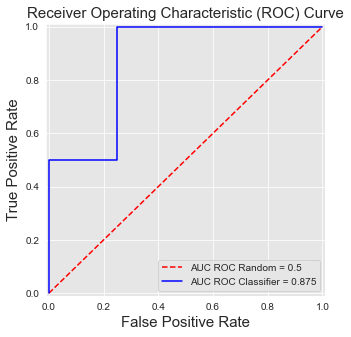

In [ ]:
roc_curve

Las curvas ROC tienen tres propiedades importantes {cite}`fernandez2018learning`. Primero, son funciones monótonas: El TPR solo puede aumentar a medida que aumenta el FPR. Segundo, el área bajo la curva tiene una interpretación probabilística: El AUC ROC puede interpretarse como la probabilidad de que las puntuaciones dadas por un clasificador clasifiquen una instancia positiva elegida al azar más alta que una instancia negativa elegida al azar. Tercero, el AUC ROC de un clasificador aleatorio es $0.5$.  

La última propiedad se puede verificar fácilmente estableciendo todas las predicciones en 0.5. Esto da una lista de solo dos umbrales. El primero es 1.5, que clasifica todas las predicciones como genuinas. El segundo es 0.5, que clasifica todas las predicciones como fraudulentas.  

In [ ]:
# 2 fraudulent and 8 genuine transactions
true_labels = [1,1,0,0,0,0,0,0,0,0]

# Probability of fraud for each transaction
fraud_probabilities = [0.5]*10

FPR_list, TPR_list, threshold = metrics.roc_curve(true_labels, fraud_probabilities, drop_intermediate=False)
FPR_list, TPR_list, threshold

(array([0., 1.]), array([0., 1.]), array([1.5, 0.5]))

In [ ]:
# %%capture
# 
# ROC_AUC = metrics.auc(FPR_list, TPR_list)    
#     
# roc_curve, ax = plt.subplots(figsize=(5,5))
# get_template_roc_curve(ax, "Receiver Operating Characteristic (ROC) Curve\n Random classifier",fs=15,random=False)
# ax.plot(FPR_list, TPR_list, 'b', color='blue', label = 'AUC ROC Classifier = {0:0.3f}'.format(ROC_AUC))
# ax.legend(loc = 'lower right')

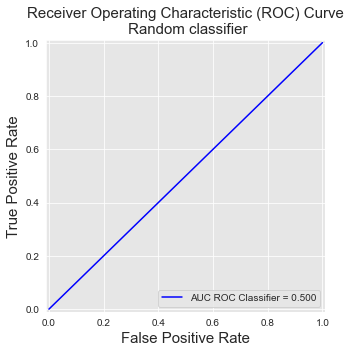

In [ ]:
roc_curve

Esto resulta en una línea que va de [0,0] a [1,1]. El AUC ROC resultante es el área bajo esta línea, que es 0.5.

Reutilicemos ahora la configuración experimental del [sistema de detección de fraude baseline](Baseline_FDS) presentado en el Capítulo 3. Se usa una semana de datos para entrenamiento, y una semana para prueba. Se consideran cinco modelos de predicción: regresión logística, un árbol de decisión con profundidad dos y un árbol de decisión de profundidad ilimitada, un bosque aleatorio con 25 árboles, y un modelo de boosting con parámetros por defecto. Las curvas ROC y su AUC se reportan a continuación para los cinco modelos.


In [ ]:
# Load data from the 2018-07-25 to the 2018-08-14

DIR_INPUT='./simulated-data-transformed/data' 

BEGIN_DATE = "2018-07-25"
END_DATE = "2018-08-14"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))


start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train=delta_delay=delta_test=7

(train_df,test_df)=get_train_test_set(transactions_df,start_date_training,
                                      delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_test)

output_feature="TX_FRAUD"

input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']

classifiers_dictionary={'Logistic regression':sklearn.linear_model.LogisticRegression(random_state=0), 
                        'Decision tree with depth of two':sklearn.tree.DecisionTreeClassifier(max_depth=2,random_state=0), 
                        'Decision tree - unlimited depth':sklearn.tree.DecisionTreeClassifier(random_state=0), 
                        'Random forest':sklearn.ensemble.RandomForestClassifier(random_state=0,n_jobs=-1),
                        'XGBoost':xgboost.XGBClassifier(random_state=0,n_jobs=-1),
                       }

fitted_models_and_predictions_dictionary={}

for classifier_name in classifiers_dictionary:
    
    start_time=time.time()
    model_and_predictions = fit_model_and_get_predictions(classifiers_dictionary[classifier_name], train_df, test_df, 
                                                          input_features=input_features,
                                                          output_feature=output_feature)
    
    print("Time to fit the "+classifier_name+" model: "+str(round(time.time()-start_time,2)))
    
    fitted_models_and_predictions_dictionary[classifier_name]=model_and_predictions
    

Load  files
CPU times: user 196 ms, sys: 155 ms, total: 351 ms
Wall time: 375 ms
201295 transactions loaded, containing 1792 fraudulent transactions
Time to fit the Logistic regression model: 0.73
Time to fit the Decision tree with depth of two model: 0.45
Time to fit the Decision tree - unlimited depth model: 1.3
Time to fit the Random forest model: 9.15
[10:53:15] WARNING: /private/var/folders/wz/86tkhhmd5gxgh4f24bdl9l2m0000gn/T/pip-install-o8iul8v_/xgboost/build/temp.macosx-10.9-x86_64-3.8/xgboost/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Time to fit the XGBoost model: 7.49


In [ ]:
# %%capture
# roc_curve, ax = plt.subplots(1, 1, figsize=(5,5))
# 
# cmap = plt.get_cmap('jet')
# colors={'Logistic regression':cmap(0), 'Decision tree with depth of two':cmap(200), 
#         'Decision tree - unlimited depth':cmap(250),
#         'Random forest':cmap(70), 'XGBoost':cmap(40)}
# 
# get_template_roc_curve(ax,title='Receiver Operating Characteristic Curve\nTest data',fs=15)
#     
# for classifier_name in classifiers_dictionary:
#     
#     model_and_predictions=fitted_models_and_predictions_dictionary[classifier_name]
# 
#     FPR_list, TPR_list, threshold = metrics.roc_curve(test_df[output_feature], model_and_predictions['predictions_test'])
#     ROC_AUC = metrics.auc(FPR_list, TPR_list)
# 
#     ax.plot(FPR_list, TPR_list, 'b', color=colors[classifier_name], label = 'AUC ROC {0}= {1:0.3f}'.format(classifier_name,ROC_AUC))
#     ax.legend(loc = 'upper left',bbox_to_anchor=(1.05, 1))
#     

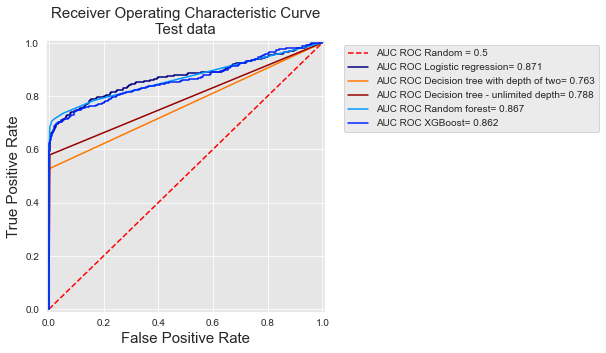

In [ ]:
roc_curve

Las curvas muestran que los árboles de decisión tienen los rendimientos más bajos, mientras que el bosque aleatorio, la regresión logística y el boosting tienen rendimientos similares. Podemos notar que las curvas para los dos árboles de decisión tienen solo unos pocos puntos. Para el árbol con profundidad dos, la razón es que solo tiene cuatro hojas, por lo que solo predice cuatro valores diferentes, y por lo tanto solo tiene cuatro umbrales posibles. Para el árbol con profundidad ilimitada, la razón es que todas sus hojas son puras en el conjunto de entrenamiento (predicen una probabilidad de 1 o una probabilidad de 0). Por lo tanto, este modelo solo tiene dos umbrales posibles.

Las curvas ROC son relevantes para tener una idea del rendimiento de un clasificador en todo el rango de FPR posibles. Su interés para la detección de fraude es sin embargo limitado ya que un objetivo importante de la detección de fraude es mantener el FPR muy bajo. 

Para tener una idea de qué tan bajo debe mantenerse el FPR, recordemos que los falsos positivos son transacciones genuinas que se predicen como fraudulentas. En un sistema operativo de fraude, estas transacciones necesitarán ser manejadas manualmente por investigadores. Debido al número limitado de investigadores, solo hay una cantidad limitada de transacciones que se pueden verificar. 

Consideremos más concretamente cómo esta restricción se traduce en términos de FPR. 

En este ejemplo, el conjunto de datos contiene 58264 transacciones (durante 7 días), de las cuales 57879 son genuinas, y 385 fraudulentas.

In [ ]:
test_df[test_df.TX_FRAUD==0].shape

(57879, 23)

In [ ]:
test_df[test_df.TX_FRAUD==1].shape

(385, 23)

Suponiendo que se pueden verificar 100 transacciones cada día, se podrían verificar un total de 700 transacciones después de 7 días, es decir, alrededor del 1% de las transacciones. Por lo tanto, cualquier FPR superior a 0.01 generará más alertas de las que pueden ser manejadas por los investigadores.

Los sistemas de detección de fraude del mundo real típicamente manejan cientos de miles a millones de transacciones diariamente. La proporción de transacciones que se pueden verificar manualmente es de hecho más cercana al 0.1% que al 1%. Es decir, cualquier FPR superior a 0.001 ya es demasiado alto. 

Como resultado, debido a la naturaleza desbalanceada del problema, el 99.9% de lo que se representa en la curva ROC tiene poca relevancia desde la perspectiva de un sistema operativo de detección de fraude donde las transacciones fraudulentas deben ser verificadas por un equipo limitado de investigadores. 

Remitimos al lector a {cite}`saito2015precision` para una discusión en profundidad sobre la inadecuación de la curva ROC para problemas desbalanceados, y las motivaciones para usar la curva Precision-Recall en su lugar.  

(Precision_Recall_Curve)=
## Precision-Recall curve

La curva Precision-Recall (curva PR) se obtiene graficando la precisión contra el recall (o Tasa de Verdaderos Positivos - TPR) para todos los diferentes umbrales de clasificación $t$. La principal ventaja de la curva PR es poner en evidencia clasificadores que pueden tener tanto un alto recall como una alta precisión (lo que indirectamente se traduce en un alto TPR y un bajo FPR).

Reutilicemos el mismo ejemplo de arriba, y calculemos la precisión y el recall para los ocho umbrales únicos.


In [ ]:
# 2 fraudulent and 8 genuine transactions
true_labels = [1,1,0,0,0,0,0,0,0,0]

# Probability of fraud for each transaction
fraud_probabilities = [0.9,0.35,0.45,0.4,0.2,0.2,0.2,0.1,0.1,0]

unique_thresholds = [1.1]+list(set(fraud_probabilities))
unique_thresholds.sort(reverse=True)

performance_metrics=threshold_based_metrics(fraud_probabilities, true_labels, unique_thresholds)
performance_metrics[['Threshold','Precision','TPR']]

,Threshold,Precision,TPR
0,1.10,1.000000,0.0
1,0.90,1.000000,0.5
2,0.45,0.500000,0.5
3,0.40,0.333333,0.5
4,0.35,0.500000,1.0
5,0.20,0.285714,1.0
6,0.10,0.222222,1.0
7,0.00,0.200000,1.0


Grafiquemos ahora la curva PR, y calculemos su AUC. Usaremos la Precisión Promedio (AP), que resume tal gráfico como la media ponderada de las precisiones logradas en cada umbral, con el aumento en el recall desde el umbral anterior usado como el peso {cite}`boyd2013area,fan2011detection`.

$$
AP=\sum_n(R_n-R_{n-1})*P_n
$$

donde $P_n$ y $R_n$ son la precisión y el recall en el $n$-ésimo umbral. 

Una implementación de la precisión promedio se proporciona a continuación.

In [ ]:
def compute_AP(precision, recall):
    
    AP = 0
    
    n_thresholds = len(precision)
    
    for i in range(1, n_thresholds):
        
        if recall[i]-recall[i-1]>=0:
            
            AP = AP+(recall[i]-recall[i-1])*precision[i]
        
    return AP

The plotting is obtained by using the `step` function from `matplotlib`.

In [ ]:
# %%capture
# def get_template_pr_curve(ax, title,fs, baseline=0.5):
#     ax.set_title(title, fontsize=fs)
#     ax.set_xlim([-0.01, 1.01])
#     ax.set_ylim([-0.01, 1.01])
#     
#     ax.set_xlabel('Recall (True Positive Rate)', fontsize=fs)
#     ax.set_ylabel('Precision', fontsize=fs)
#     
#     ax.plot([0, 1], [baseline, baseline],'r--',label='AP Random = {0:0.3f}'.format(baseline))
# 
# precision = performance_metrics.Precision.values
# recall = performance_metrics.TPR.values
#     
# pr_curve, ax = plt.subplots(figsize=(5,5))
# get_template_pr_curve(ax, "Precision Recall (PR) Curve",fs=15,baseline=sum(true_labels)/len(true_labels))
# AP2 = metrics.average_precision_score(true_labels, fraud_probabilities)
# AP = compute_AP(precision, recall)
# ax.step(recall, precision, 'b', color='blue', label = 'AP Classifier = {0:0.3f}'.format(AP))
# ax.legend(loc = 'lower right')


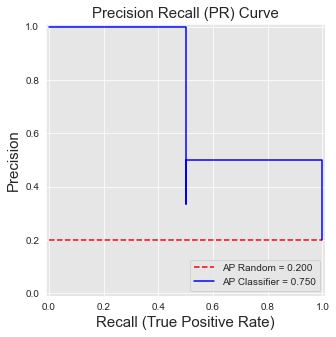

In [ ]:
pr_curve

Las curvas PR se comportan de manera diferente a las curvas ROC. Detallamos estas diferencias a continuación. 

Primero, no son monótonas: La precisión puede disminuir o aumentar, a medida que aumenta el recall. Esto se ilustra arriba, donde para un recall de $0.5$, la precisión primero baja a $0.33$ (umbral $0.4$), antes de subir a $0.5$ (umbral $0.35$). 

Segundo, su AUC no lleva una interpretación estadística como el AUC ROC. Sin embargo, se puede demostrar que existe una correspondencia uno a uno entre las curvas PR y ROC, y que una curva que domina en el espacio PR necesariamente domina en el espacio ROC {cite}`davis2006relationship`. 

Tercero, el rendimiento de un clasificador aleatorio depende del desbalance de clases. Es $0.5$ en el caso balanceado, y $P/(P+N)$ en el caso general, donde $P$ es el número de ejemplos positivos, y $N$ el número de ejemplos negativos. En particular, un clasificador que clasifica todos los ejemplos como positivos (recall de 1) tiene una precisión de $P/(P+N)$. En el ejemplo anterior, esto da una precisión de $2/(2+8)=0.2$, resaltada con la línea roja punteada. Esta propiedad hace que el AP sea más interesante que el AUC ROC en un problema de detección de fraude, ya que refleja mejor el desafío relacionado con el problema de desbalance de clases (el AP de un clasificador aleatorio disminuye a medida que aumenta la proporción de desbalance de clases).  

```{warning}
La interpolación lineal (como se usa para las curvas ROC) no debe usarse para graficar curvas PR, ni para evaluar su AUC. El uso de la función escalonada para graficar, y AP como medida de AUC están bien establecidos. Remitimos al lector a {cite}`saito2015precision,flach2015precision,davis2006relationship` para discusiones detalladas sobre el tema, y el uso de formas alternativas de graficar la curva PR o evaluar su AUC.  
```

Finalmente reutilicemos la configuración experimental de la sección anterior, y grafiquemos las curvas PR y el AP correspondiente para cada uno de los cinco modelos de predicción.

In [ ]:
# %%capture
# pr_curve, ax = plt.subplots(1, 1, figsize=(6,6))
# cmap = plt.get_cmap('jet')
# colors={'Logistic regression':cmap(0), 'Decision tree with depth of two':cmap(200), 
#         'Decision tree - unlimited depth':cmap(250),
#         'Random forest':cmap(70), 'XGBoost':cmap(40)}
# 
# get_template_pr_curve(ax, "Precision Recall (PR) Curve\nTest data",fs=15,baseline=sum(test_df[output_feature])/len(test_df[output_feature]))
#     
# for classifier_name in classifiers_dictionary:
#     
#     model_and_predictions=fitted_models_and_predictions_dictionary[classifier_name]
# 
#     precision, recall, threshold = metrics.precision_recall_curve(test_df[output_feature], model_and_predictions['predictions_test'])
#     precision=precision[::-1]
#     recall=recall[::-1]
#     
#     AP = metrics.average_precision_score(test_df[output_feature], model_and_predictions['predictions_test'])
#     
#     ax.step(recall, precision, 'b', color=colors[classifier_name], label = 'AP {0}= {1:0.3f}'.format(classifier_name,AP))
#     ax.legend(loc = 'upper left',bbox_to_anchor=(1.05, 1))
#     
#     
# plt.subplots_adjust(wspace=0.5, hspace=0.8)

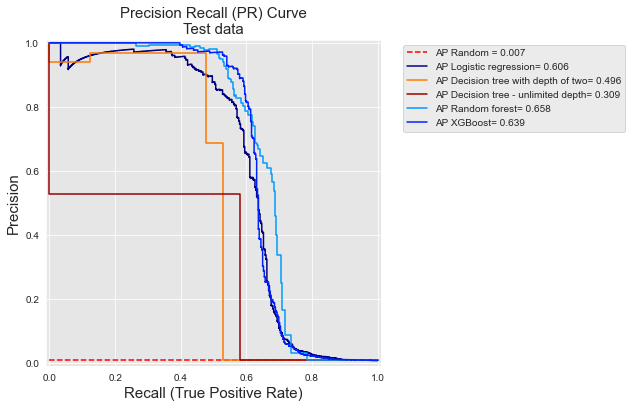

In [ ]:
pr_curve

And let us compare these PR curves with the ROC curves.

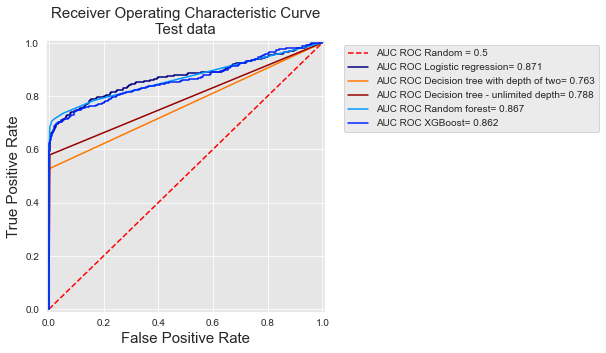

In [ ]:
roc_curve

At first sight, PR and ROC curves give a very different picture of the relative performances of the different classifiers. In order to better relate the two types of curve, it is useful to mentally 'transpose' the PR curve in such a way that the x-axis represents the precision, and the y-axis represents the True Positive Rate. Once transposed, both curves represent the TPR on their y-axis, and one can note that the PR curve is actually a zoomed version of the ROC curves for very low values of the False Positive Rate.

As pointed out above at the end of the section on ROC curves, the TPR for low FPR values is actually what matters in a fraud detection problem: The number of cards that can be manually checked by fraud investigators is in practice very limited. This also gives a different ordering of performances for the classifiers. For example, with ROC curves, decision trees with unlimited depth have a better AUC than a decision tree of depth two (0.788 versus 0.763, respectively). The performances are reversed when computed in terms of Average Precision (0.309 versus 0.496). 

While PR curves are useful to highlight the performances of fraud detection systems for low FPR values, they however remain difficult to interpret from an operational point of view. The next section addresses this issue, by discussing [Precision top-$k$ metrics](Precision_Top_K_Metrics).
 


---

## TopKBased


(Precision_Top_K_Metrics)=
# Métricas de precisión top-k

Esta sección aborda la relevancia de un FDS de tarjeta de crédito desde una perspectiva más operativa, considerando explícitamente sus beneficios para los investigadores de fraude. Recordemos primero que el propósito de un FDS es proporcionar a los investigadores *alertas*, es decir, un conjunto de transacciones que se asume que son las más sospechosas (ver Sección {ref}`Fraud_Detection_System`). Estas transacciones se verifican manualmente, contactando al titular de la tarjeta. El proceso de contactar a los titulares de tarjetas consume tiempo, y el número de investigadores de fraude es limitado. El número de alertas que pueden verificarse durante un período dado es por lo tanto necesariamente limitado.

Las métricas *Precision top-$k$* tienen como objetivo cuantificar el rendimiento de un FDS en este contexto {cite}`dal2017credit,dal2015adaptive,fan2011detection`. Las precisiones se calculan diariamente, reflejando las precisiones obtenidas para un día laboral de investigadores de fraude. El parámetro $k$ cuantifica el número máximo de alertas que pueden ser verificadas por los investigadores en un día. 

Formalmente, para un día $d$, denotemos por $\mathcal{T}_d$ el conjunto de transacciones. Solo una minoría de transacciones $\mathcal{T}_d^{Fraud} \subset \mathcal{T}_d$ es fraudulenta, mientras que la mayoría $\mathcal{T}_d^{Genuine} \subset \mathcal{T}_d$ son genuinas. Denotemos además por $\mathcal{A}_d$ el conjunto de alertas. El conjunto de alertas contiene tanto verdaderos positivos ($\mathcal{A}_d^{Fraud}$), como falsos positivos ($\mathcal{A}_d^{Genuine}$). La Fig. 1 proporciona una ilustración esquemática.  

![](images/hits_per_day_with_caption.png)

Denotando por $k$ el número de alertas que los investigadores pueden procesar durante un día, y por $|.|$ la cardinalidad de un conjunto, tenemos $|\mathcal{A}_d|=k$, con $k << |\mathcal{T}_d|$. 

En este contexto, el rendimiento de un clasificador es maximizar la precisión en el subconjunto $\mathcal{A}_d$, es decir, maximizar

$$P@k(d)=\frac{|\mathcal{A}_d^{Fraud}|}{|\mathcal{A}_d|}=\frac{|\mathcal{A}_d^{Fraud}|}{k}$$

Esta cantidad se conoce como *Precisión top-$k$ para el día $d$* {cite}`dal2017credit,dal2015adaptive`, o $P@k(d)$. Una alternativa a esta medida es la *Precisión de Tarjetas top-$k$*, que mide la *Precisión top-$k$* en términos de tarjetas en lugar de transacciones autorizadas. Múltiples transacciones en $|A_d|$ de la misma tarjeta deben contarse como una sola alerta ya que los investigadores verifican todas las transacciones recientes al contactar a los titulares de tarjetas. La *Precisión de Tarjetas top-$k$ para el día $d$* se conoce como $CP@k(d)$. 

Detallamos ambas métricas a continuación, junto con sus implementaciones. 


In [ ]:
# Initialization: Load shared functions and simulated data 

# Load shared functions
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

# Get simulated data from Github repository
if not os.path.exists("simulated-data-transformed"):
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed
        

## Precisión top-$k$

Reutilicemos la [configuración de detección de fraude baseline](Baseline_FDS), usando una semana de datos para entrenamiento, y una semana de datos para probar los rendimientos de detección. Se usa un árbol de decisión de profundidad dos como modelo de predicción.


In [ ]:
# Load data from the 2018-07-25 to the 2018-08-14

DIR_INPUT='./simulated-data-transformed/data/' 

BEGIN_DATE = "2018-07-25"
END_DATE = "2018-08-14"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))

start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train=delta_delay=delta_test=7

(train_df,test_df)=get_train_test_set(transactions_df,start_date_training,
                                      delta_train=delta_train,delta_delay=delta_delay,delta_test=delta_test)

output_feature="TX_FRAUD"

input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']

classifier = sklearn.tree.DecisionTreeClassifier(max_depth = 2, random_state=0)

model_and_predictions_dictionary = fit_model_and_get_predictions(classifier, train_df, test_df, 
                                                                 input_features, output_feature)    

Load  files
CPU times: user 47.8 ms, sys: 49 ms, total: 96.8 ms
Wall time: 140 ms
201295 transactions loaded, containing 1792 fraudulent transactions


The predictions for the test week are returned in the `predictions_test` entry of the `model_and_predictions_dictionary` dictionary. `predictions_test` is a vector that contains the fraud probabilities for each of the transactions in the `test_df` DataFrame. We can check that the number of predictions equals the number of transactions:

In [ ]:
assert len(model_and_predictions_dictionary['predictions_test'])==len(test_df)

Agreguemos estas predicciones como una nueva columna en el DataFrame de transacciones de prueba, y mostremos las cinco primeras filas.

In [ ]:
predictions_df=test_df
predictions_df['predictions']=model_and_predictions_dictionary['predictions_test']
predictions_df[['TRANSACTION_ID','TX_DATETIME','CUSTOMER_ID','TERMINAL_ID','TX_AMOUNT','TX_TIME_DAYS','TX_FRAUD','predictions']].head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_DAYS,TX_FRAUD,predictions
134215,1236698,2018-08-08 00:01:14,2765,2747,-0.266899,129,0,0.003536
134216,1236699,2018-08-08 00:02:33,714,2073,1.295440,129,0,0.003536
134218,1236701,2018-08-08 00:08:40,4982,1258,-0.650902,129,0,0.003536
134219,1236702,2018-08-08 00:08:41,704,8501,0.290249,129,0,0.003536
134220,1236703,2018-08-08 00:10:34,3085,4208,0.039070,129,0,0.003536


The $P@k(d)$ can be computed for a day $d$ by ranking all fraud probabilities by decreasing order, and computing the precision for the top $k$ ranked transactions. Let us for example compute the precision obtained on the top 100 transactions, for the first day of transactions in the test set (day 129).

In [ ]:
def precision_top_k_day(df_day, top_k=100):
    
    # Ordenar transacciones por probabilidades decrecientes de fraudes
    df_day = df_day.sort_values(by="predictions", ascending=False).reset_index(drop=False)
        
    # Obtener las k transacciones más sospechosas
    df_day_top_k=df_day.head(top_k)
    list_detected_fraudulent_transactions=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].TRANSACTION_ID)
    
    # Compute precision top k
    precision_top_k = len(list_detected_fraudulent_transactions) / top_k
    
    return list_detected_fraudulent_transactions, precision_top_k


day=129

df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
df_day = df_day[['TRANSACTION_ID','CUSTOMER_ID', 'TX_FRAUD', 'predictions']]

_, precision_top_k= precision_top_k_day(df_day=df_day, top_k=100)
precision_top_k


0.26

Obtenemos una precisión de 0.26, es decir, 26 de las cien transacciones más altamente sospechosas eran efectivamente transacciones fraudulentas. 

Debe notarse que el valor más alto que es alcanzable para el $P@k(d)$ puede ser menor que uno. Este es el caso cuando $k$ es mayor que el número de transacciones fraudulentas para un día dado. En el ejemplo anterior, el número de transacciones fraudulentas en el día 129 es 55.

In [ ]:
df_day.TX_FRAUD.sum()

55

As a result, the maximum $P@100(129)$ which can be achieved is 55/100=0.55.

When a test set spans multiple days, let $P@k$ be the mean of $P@k(d)$ for a set of days $d \in \mathcal{D}$ {cite}`dal2017credit,dal2015adaptive`, that is:

$$
P@k = \frac{1}{|\mathcal{D}|}\sum_{d \in \mathcal{D}} P_k(d)
$$

Let us implement this score with a function `precision_top_k`, which takes as input a `predictions_df` DataFrame, and a `top_k` threshold. The function loops over all days of the DataFrame, and computes for each day the number of fraudulent transactions and the precision top-$k$. It returns these values for all days as lists, together with the resulting mean of the precisions top-$k$.  

In [ ]:
def precision_top_k(predictions_df, top_k=100):

    # Sort days by increasing order
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()
    
    precision_top_k_per_day_list = []
    nb_fraudulent_transactions_per_day = []
    
    # For each day, compute precision top k
    for day in list_days:
        
        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['TRANSACTION_ID', 'CUSTOMER_ID', 'TX_FRAUD', 'predictions']]
        
        nb_fraudulent_transactions_per_day.append(len(df_day[df_day.TX_FRAUD==1]))
        
        _, _precision_top_k = precision_top_k_day(df_day, top_k=top_k)
        
        precision_top_k_per_day_list.append(_precision_top_k)
        
    # Compute the mean
    mean_precision_top_k = np.round(np.array(precision_top_k_per_day_list).mean(),3)
    
    # Returns number of fraudulent transactions per day,
    # precision top k per day, and resulting mean
    return nb_fraudulent_transactions_per_day,precision_top_k_per_day_list,mean_precision_top_k


Applying this function to the `prediction_df`, with $k=100$, we get:

In [ ]:
nb_fraudulent_transactions_per_day_remaining,\
precision_top_k_per_day_list,\
mean_precision_top_k = precision_top_k(predictions_df=predictions_df, top_k=100)

print("Number of remaining fraudulent transactions: "+str(nb_fraudulent_transactions_per_day_remaining))
print("Precision top-k: "+str(precision_top_k_per_day_list))
print("Average Precision top-k: "+str(mean_precision_top_k))

Number of remaining fraudulent transactions: [55, 60, 56, 56, 59, 58, 41]
Precision top-k: [0.26, 0.35, 0.26, 0.33, 0.3, 0.35, 0.19]
Average Precision top-k: 0.291


Para una mejor visualización, grafiquemos estos datos. Reutilizamos la función de graficación introducida en {ref}`Baseline_FDS_Training_Test_Sets` (importada del cuaderno de [funciones compartidas](shared_functions)). Primero, usamos la función `get_tx_stats` para calcular el número de transacciones por día, transacciones fraudulentas por día y tarjetas comprometidas por día. Luego agregamos las transacciones fraudulentas *restantes* por día, y la precisión top-$k$ por día al DataFrame, para los siete días del período de prueba.

In [ ]:
# Compute the number of transactions per day, 
#fraudulent transactions per day and fraudulent cards per day
tx_stats=get_tx_stats(transactions_df, start_date_df="2018-04-01")

# Add the remaining number of fraudulent transactions for the last 7 days (test period)
tx_stats.loc[14:20,'nb_fraudulent_transactions_per_day_remaining']=list(nb_fraudulent_transactions_per_day_remaining)
# Add precision top k for the last 7 days (test period) 
tx_stats.loc[14:20,'precision_top_k_per_day']=precision_top_k_per_day_list


Tenga en cuenta que el número *restante* de transacciones fraudulentas es el número de transacciones fraudulentas originalmente presentes en el período de prueba, menos aquellas transacciones que pertenecen a tarjetas conocidas como comprometidas en el conjunto de entrenamiento (ver función `get_train_test_set`). Recordamos que estas transacciones deben eliminarse al evaluar el rendimiento del detector de fraude en el conjunto de prueba, ya que las tarjetas a las que pertenecen eran conocidas como comprometidas al entrenar el detector de fraude. 

In [ ]:
# %%capture
# 
# # Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day
# 
# cmap = plt.get_cmap('jet')
# colors={'precision_top_k_per_day':cmap(0), 
#         'nb_fraudulent_transactions_per_day':cmap(200),
#         'nb_fraudulent_transactions_per_day_remaining':cmap(250),
#        }
# 
# fraud_and_transactions_stats_fig, ax = plt.subplots(1, 1, figsize=(15,8))
# 
# # Training period
# start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
# delta_train = delta_delay = delta_test = 7
# 
# end_date_training = start_date_training+datetime.timedelta(days=delta_train-1)
# 
# # Test period
# start_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay)
# end_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay+delta_test-1)
# 
# get_template_tx_stats(ax, fs=20,
#                       start_date_training=start_date_training,
#                       title='Number of fraudulent transactions per day \n and number of detected fraudulent transactions',
#                       delta_train=delta_train,
#                       delta_delay=delta_delay,
#                       delta_test=delta_test,
#                       ylim=150
#                      )
# 
# ax.plot(tx_stats['tx_date'], tx_stats['nb_fraudulent_transactions_per_day'], 'b', color=colors['nb_fraudulent_transactions_per_day'], label = '# fraudulent txs per day - Original')
# ax.plot(tx_stats['tx_date'], tx_stats['nb_fraudulent_transactions_per_day_remaining'], 'b', color=colors['nb_fraudulent_transactions_per_day_remaining'], label = '# fraudulent txs per day - Remaining')
# ax.plot(tx_stats['tx_date'], tx_stats['precision_top_k_per_day']*100, 'b', color=colors['precision_top_k_per_day'], label = '# detected fraudulent txs per day')
# ax.legend(loc = 'upper left',bbox_to_anchor=(1.05, 1),fontsize=20)
#     

The resulting plot gives us 

* the number of fraudulent transactions originally present in the transaction dataset, for the training, delay, and test period
* the number of remaining transactions for the test period (original, minus those belonging to cards known to be fraudulent in the training period)
* the number of detected fraudulent transactions for the test period (precision top-$k$ times $k$). 

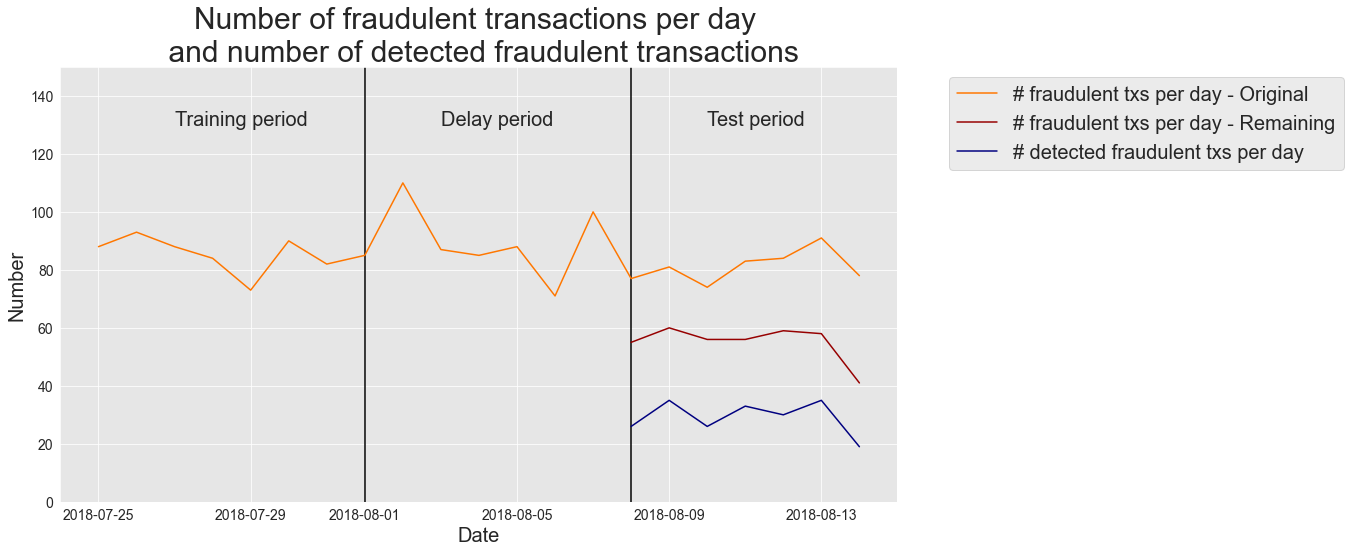

In [ ]:
fraud_and_transactions_stats_fig

The graph shows a well-detailed summary of the performance of the fraud detector from an operational point of view. In the test period, the number of fraudulent transactions varied between 74 and 91. Once known compromised cards from the training period were removed, the remaining fraudulent transactions varied between 41 and 60. Out of these remaining fraudulent transactions, the fraud detector correctly detected between 19 and 35 transactions, with an average number of 29 fraudulent transactions detected per day (average precision top-$k$=0.29), that is, about 50% of the actual fraudulent transactions were detected.  

(Card_Precision_Top_K)=
## Precisión de Tarjetas top-$k$

Como se señaló en la introducción, múltiples transacciones fraudulentas de la misma tarjeta deben contarse como una sola detección correcta ya que los investigadores verifican todas las transacciones recientes al contactar a los titulares de tarjetas. La métrica resultante es la *Precisión de Tarjetas Top-$k$*, o $CP@k$, y cuantifica el número de tarjetas comprometidas correctamente detectadas de las $k$ tarjetas que tienen los mayores riesgos de fraudes.

$CP@k$ se puede calcular modificando ligeramente la implementación de la Precisión top-$k$ dada arriba. Más específicamente, en lugar de simplemente ordenar transacciones por orden decreciente de sus probabilidades de fraude, primero agrupamos transacciones por ID de cliente. Para cada ID de cliente, luego tomamos el valor máximo de la probabilidad de fraude y la etiqueta de fraude. Esto se puede calcular en una sola línea de código con los operadores `group_by` y `max` de Panda. La precisión de tarjetas top-$k$ finalmente se calcula ordenando los IDs de cliente por orden decreciente de las probabilidades de fraude y calculando la precisión para el conjunto de $k$ tarjetas con las mayores probabilidades de fraude. 

Esto se implementa a continuación con la función `card_precision_top_k_day`. De manera similar a `precision_top_k_day`, la función toma como entrada un conjunto de transacciones para un día dado y un valor top-$k$. Devuelve la lista de tarjetas comprometidas detectadas, y la precisión de tarjetas top-$k$ para ese día. Como ejemplo, calculemos la precisión obtenida en las 100 tarjetas principales, para el primer día de transacciones en el conjunto de prueba (día 129).

In [ ]:
def card_precision_top_k_day(df_day, top_k):
    
    # This takes the max of the predictions AND the max of label TX_FRAUD for each CUSTOMER_ID, 
    # and sorts by decreasing order of fraudulent prediction
    df_day = df_day.groupby('CUSTOMER_ID').max().sort_values(by="predictions", ascending=False).reset_index(drop=False)
    
    # Get the top k most suspicious cards
    df_day_top_k=df_day.head(top_k)
    list_detected_compromised_cards=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].CUSTOMER_ID)
    
    # Compute precision top k
    card_precision_top_k = len(list_detected_compromised_cards) / top_k
    
    return list_detected_compromised_cards, card_precision_top_k

day=129

df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]

_,card_precision_top_k= card_precision_top_k_day(df_day=df_day, top_k=100)
card_precision_top_k


0.24

We get a card precision of 0.24, that is, 24 out of the first one hundred most highly suspicious cards were indeed compromised cards. The number of compromised cards on day 129 was 50. 

In [ ]:
df_day.groupby('CUSTOMER_ID').max().TX_FRAUD.sum()

50

Close to 50% of the compromised cards were therefore detected. Computing the Card Precision top-$k$ over several days is achieved the same way as for the Precision Top-$k$, by computing the Card Precision top-$k$ for each day of the test period, and taking the mean. 

In [ ]:
def card_precision_top_k(predictions_df, top_k):

    # Sort days by increasing order
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()
    
    card_precision_top_k_per_day_list = []
    nb_compromised_cards_per_day = []
    
    # For each day, compute precision top k
    for day in list_days:
        
        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]
        
        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))
        
        _, card_precision_top_k = card_precision_top_k_day(df_day,top_k)
        
        card_precision_top_k_per_day_list.append(card_precision_top_k)
        
    # Compute the mean
    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()
    
    # Returns precision top k per day as a list, and resulting mean
    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k


In [ ]:
nb_compromised_cards_per_day_remaining\
,card_precision_top_k_per_day_list\
,mean_card_precision_top_k=card_precision_top_k(predictions_df=predictions_df, top_k=100)

print("Number of remaining compromised cards: "+str(nb_compromised_cards_per_day_remaining))
print("Precision top-k: "+str(card_precision_top_k_per_day_list))
print("Average Precision top-k: "+str(mean_card_precision_top_k))


Number of remaining compromised cards: [50, 54, 51, 54, 55, 54, 38]
Precision top-k: [0.24, 0.35, 0.26, 0.32, 0.3, 0.34, 0.19]
Average Precision top-k: 0.2857142857142857


Grafiquemos estos resultados para una mejor visualización.

In [ ]:
# Compute the number of transactions per day, 
# fraudulent transactions per day and fraudulent cards per day
tx_stats=get_tx_stats(transactions_df, start_date_df="2018-04-01")

# Add the remaining number of compromised cards for the last 7 days (test period)
tx_stats.loc[14:20,'nb_compromised_cards_per_day_remaining']=list(nb_compromised_cards_per_day_remaining)

# Add the card precision top k for the last 7 days (test period) 
tx_stats.loc[14:20,'card_precision_top_k_per_day']=card_precision_top_k_per_day_list


In [ ]:
# %%capture
# 
# # Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day
# 
# cmap = plt.get_cmap('jet')
# colors={'card_precision_top_k_per_day':cmap(0), 
#         'nb_compromised_cards_per_day':cmap(200),
#         'nb_compromised_cards_per_day_remaining':cmap(250),
#        }
# 
# fraud_and_transactions_stats_fig, ax = plt.subplots(1, 1, figsize=(15,8))
# 
# # Training period
# start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
# delta_train = delta_delay = delta_test = 7
# 
# end_date_training = start_date_training+datetime.timedelta(days=delta_train-1)
# 
# # Test period
# start_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay)
# end_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay+delta_test-1)
# 
# get_template_tx_stats(ax, fs=20,
#                       start_date_training=start_date_training,
#                       title='Number of fraudulent transactions per day \n and number of detected fraudulent transactions',
#                       delta_train=delta_train,
#                       delta_delay=delta_delay,
#                       delta_test=delta_test,
#                       ylim=150
#                      )
# 
# ax.plot(tx_stats['tx_date'], tx_stats['nb_compromised_cards_per_day'], 'b', color=colors['nb_compromised_cards_per_day'], label = '# fraudulent txs per day - Original')
# ax.plot(tx_stats['tx_date'], tx_stats['nb_compromised_cards_per_day_remaining'], 'b', color=colors['nb_compromised_cards_per_day_remaining'], label = '# compromised cards per day - Remaining')
# ax.plot(tx_stats['tx_date'], tx_stats['card_precision_top_k_per_day']*100, 'b', color=colors['card_precision_top_k_per_day'], label = '# detected compromised cards per day')
# ax.legend(loc = 'upper left', bbox_to_anchor=(1.05, 1), fontsize=20)
#     

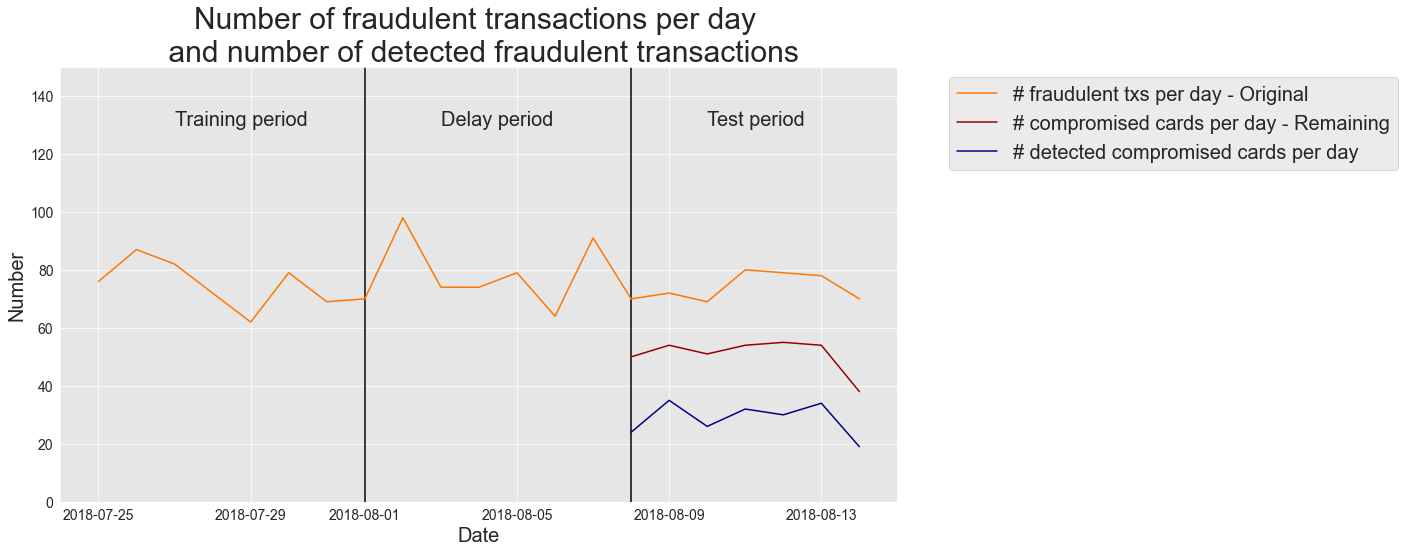

In [ ]:
fraud_and_transactions_stats_fig

The results are qualitatively similar to those obtained using the Precision top-$k$. In the test period, the number of compromised cards varied between 69 and 80. Once transactions from known compromised cards were removed, the remaining compromised cards varied between 38 and 55. Out of these remaining compromised cards, the fraud detector correctly detected between 19 and 35 cards, with an average number of 29 compromised cards detected per day (average Card Precision Top-$k$=0.33), that is, about 60% of the actual compromised cards were detected.  

Finalmente, debe notarse que una vez que se ha detectado una tarjeta comprometida, se bloquea y por lo tanto debe eliminarse del conjunto de transacciones. Modifiquemos el `card_precision_top_k` para eliminar las tarjetas comprometidas que han sido detectadas.

In [ ]:
def card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True):

    # Ordenar días por orden creciente
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()
    
    # Al principio, la lista de tarjetas comprometidas detectadas está vacía
    list_detected_compromised_cards = []
    
    card_precision_top_k_per_day_list = []
    nb_compromised_cards_per_day = []
    
    # For each day, compute precision top k
    for day in list_days:
        
        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]
        
        # Eliminemos las tarjetas comprometidas detectadas del conjunto de transacciones diarias
        df_day = df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)==False]
        
        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))
        
        detected_compromised_cards, card_precision_top_k = card_precision_top_k_day(df_day,top_k)
        
        card_precision_top_k_per_day_list.append(card_precision_top_k)
        
        # Actualicemos la lista de tarjetas comprometidas detectadas
        if remove_detected_compromised_cards:
            list_detected_compromised_cards.extend(detected_compromised_cards)
        
    # Compute the mean
    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()
    
    # Returns precision top k per day as a list, and resulting mean
    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k


In [ ]:
nb_compromised_cards_per_day_remaining\
,card_precision_top_k_per_day_list\
,mean_card_precision_top_k=card_precision_top_k(predictions_df=predictions_df, top_k=100)

print("Number of remaining compromised cards: "+str(nb_compromised_cards_per_day_remaining))
print("Precision top-k: "+str(card_precision_top_k_per_day_list))
print("Average Precision top-k: "+str(mean_card_precision_top_k))



Number of remaining compromised cards: [50, 50, 49, 47, 46, 44, 31]
Precision top-k: [0.24, 0.32, 0.27, 0.25, 0.23, 0.26, 0.12]
Average Precision top-k: 0.2414285714285714


Observamos que el número de tarjetas comprometidas restantes es menor, ya que las tarjetas comprometidas detectadas se eliminan del conjunto de transacciones.

In [ ]:
# Compute the number of transactions per day, 
#fraudulent transactions per day and fraudulent cards per day
tx_stats=get_tx_stats(transactions_df, start_date_df="2018-04-01")

# Add the remaining number of compromised cards for the last 7 days (test period)
tx_stats.loc[14:20,'nb_compromised_cards_per_day_remaining']=list(nb_compromised_cards_per_day_remaining)

# Add the card precision top k for the last 7 days (test period) 
tx_stats.loc[14:20,'card_precision_top_k_per_day']=card_precision_top_k_per_day_list


In [ ]:
# %%capture
# 
# # Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day
# 
# cmap = plt.get_cmap('jet')
# colors={'card_precision_top_k_per_day':cmap(0), 
#         'nb_compromised_cards_per_day':cmap(200),
#         'nb_compromised_cards_per_day_remaining':cmap(250),
#        }
# 
# fraud_and_transactions_stats_fig, ax = plt.subplots(1, 1, figsize=(15,8))
# 
# # Training period
# start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
# delta_train = delta_delay = delta_test = 7
# 
# end_date_training = start_date_training+datetime.timedelta(days=delta_train-1)
# 
# # Test period
# start_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay)
# end_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay+delta_test-1)
# 
# get_template_tx_stats(ax, fs=20,
#                       start_date_training=start_date_training,
#                       title='Number of fraudulent transactions per day \n and number of detected fraudulent transactions',
#                       delta_train=delta_train,
#                       delta_delay=delta_delay,
#                       delta_test=delta_test,
#                       ylim=150
#                      )
# 
# ax.plot(tx_stats['tx_date'], tx_stats['nb_compromised_cards_per_day'], 'b', color=colors['nb_compromised_cards_per_day'], label = '# compromised cards per day - Original')
# ax.plot(tx_stats['tx_date'], tx_stats['nb_compromised_cards_per_day_remaining'], 'b', color=colors['nb_compromised_cards_per_day_remaining'], label = '# compromised cards per day - Remaining')
# ax.plot(tx_stats['tx_date'], tx_stats['card_precision_top_k_per_day']*100, 'b', color=colors['card_precision_top_k_per_day'], label = '# detected compromised compromised cards per day')
# 
# ax.legend(loc = 'upper left',bbox_to_anchor=(1.05, 1),fontsize=20)

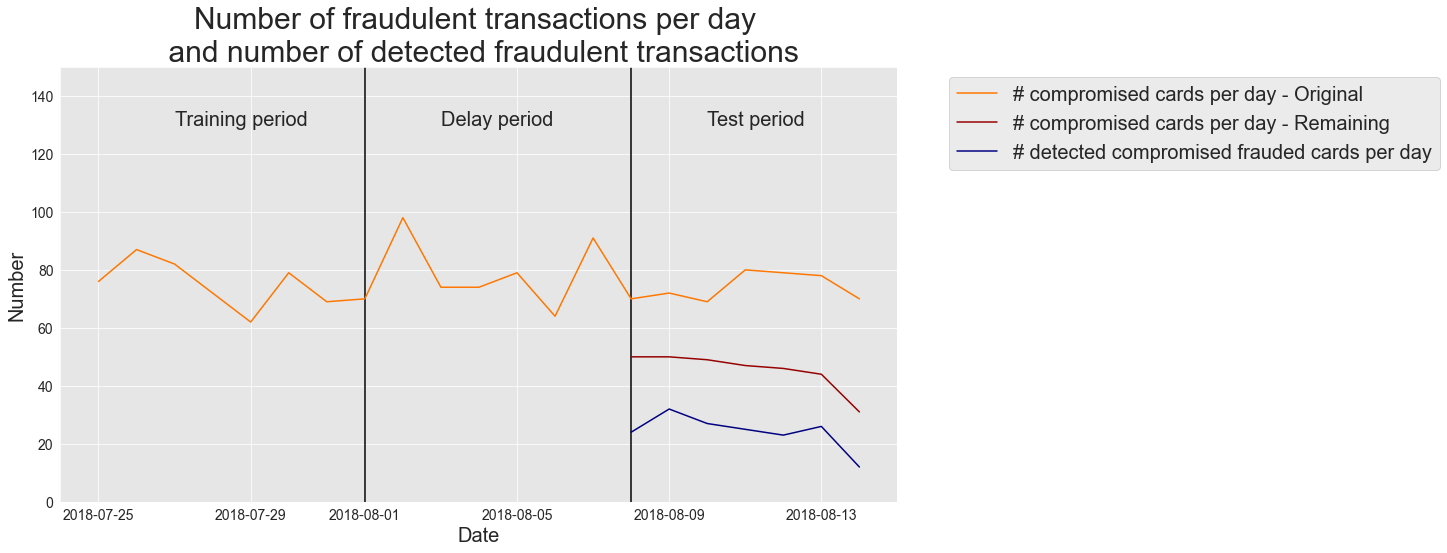

In [ ]:
fraud_and_transactions_stats_fig

This last implementation of `card_precision_top_k` is the one included in the [shared functions](shared_functions) notebook and used in the next chapters. 


---

## Assessment_RealWorldData


# Real-world data

This section extends the experimental results presented in [Chapter 3, Real-world data](Baseline_FDS_RealWorldData). We first report the ROC and AP curves for the five baseline prediction models on real-world data. We then illustrate the daily card precision with $k=100$ using a decision tree of depth 2 as the prediction model. 



## Curvas de Característica Operativa del Receptor

La Fig. 1 reporta las curvas ROC para los cinco clasificadores baseline (Regresión logística, árboles de decisión con profundidad 2 y profundidad ilimitada, bosque aleatorio, y XGBoost) en datos del mundo real. Las curvas son similares a las obtenidas con datos simulados en la Sección {ref}`Receiving_Operating_Characteristic_Curve`. Los árboles de decisión tienen los rendimientos más bajos, mientras que la regresión logística, el bosque aleatorio y XGBoost tienen rendimientos más altos.

![alt text](images/WL_ROC.png)
<p style="text-align: center;">
Fig. 1. Curvas ROC para los cinco clasificadores baseline (Regresión logística, Árboles de decisión con profundidad 2 y profundidad ilimitada, bosque aleatorio, y XGBoost) en datos del mundo real.
</p>

Se puede notar que, contrariamente a los resultados obtenidos con datos simulados, XGBoost tiene un rendimiento significativamente mejor que el bosque aleatorio y la regresión logística (AUC ROC de 0.899 versus AUC ROC de 0.78 y 0.788, respectivamente). 

## Curvas Precision-Recall

La Fig. 2 reporta las curvas PR para los mismos cinco clasificadores baseline en datos del mundo real. Las curvas son a primera vista bastante diferentes de las obtenidas con datos simulados ({ref}`Precision_Recall_Curve`).

![alt text](images/WL_AP.png)
<p style="text-align: center;">
Fig. 2. Curvas PR para los cinco clasificadores baseline (Regresión logística, Árboles de decisión con profundidad 2 y profundidad ilimitada, bosque aleatorio, y XGBoost) en datos del mundo real.
</p>

Estas diferencias son causadas por los rendimientos en términos de precisión promedio que son, en general, mucho más bajos que con datos simulados. Como resultado, todas las curvas se reducen a valores de precisión más bajos. La razón es doble. Primero, la proporción de fraudes es menor en el conjunto de datos del mundo real. Segundo, las transacciones fraudulentas también son más difíciles de detectar, lo que resulta en más falsos positivos a medida que se aumenta el umbral de detección. 

Sin embargo, los rendimientos relativos de los diferentes clasificadores son similares a los obtenidos con datos simulados. En particular, la regresión logística y XGBoost tienen rendimientos mucho más altos que los árboles de decisión. Vale la pena notar que el rendimiento del bosque aleatorio en términos de AP es sin embargo pobre, y menor que el de un árbol de decisión de profundidad dos. Esto es el resultado de sobreajuste, un problema que se abordará con [selección de modelos en el Capítulo 5](Model_Selection).  


## Precisión de Tarjetas Top-$k$

Finalmente reportamos, como en {ref}`Precision_Top_K_Metrics`, el número de tarjetas defraudadas detectadas diariamente usando datos del mundo real. Los resultados se proporcionan en la Fig. 3, para un árbol de decisión de profundidad 2.  

![alt text](images/WL_TopK.png)
<p style="text-align: center;">
Fig. 3. Número de tarjetas defraudadas detectadas diariamente con datos reales, usando un árbol de decisión de profundidad 2.
</p>

El conjunto de datos del mundo real contiene muchas más transacciones (alrededor de 400000 transacciones diarias) y como resultado, el número de tarjetas defraudadas diarias también es mayor (rango entre 280 y 420, con un promedio de alrededor de trescientas. Línea amarilla). Una vez que se eliminan las tarjetas defraudadas conocidas, el número de tarjetas que quedan por detectar oscila entre 200 y 350 (Línea roja). Recordemos que el CP@100 para un árbol de decisión de profundidad dos era 0.1 ({ref}`Baseline_FDS`), es decir, en promedio, 10 tarjetas de las 100 más sospechosas son verdaderos positivos. Esto se ilustra con la línea azul, que representa el número de tarjetas defraudadas que se detectan efectivamente cada día. 

Tenga en cuenta que el número máximo de tarjetas defraudadas correctamente detectadas está limitado superiormente por $k$. Es decir, un número máximo de 100 tarjetas defraudadas solo puede ser detectado cada día cuando $k=100$.
